In [1]:
import pandas as pd
import numpy as np
import re
import s3fs
pd.set_option('display.max_columns', None)  # mostra todas as colunas
pd.set_option('display.max_colwidth', None) # não trunca o conteúdo
pd.set_option('display.width', None) 
fs = s3fs.S3FileSystem()

bucket_name = 't2rpt'

s3_path = f's3://{bucket_name}/'

df_sinistros = pd.read_csv(f'{s3_path}atendimento_sinistros.csv', sep=",")
df_cadastro = pd.read_csv(f'{s3_path}cadastro_clientes.csv', sep=",")
df_mkt = pd.read_csv(f'{s3_path}engajamento_marketing.csv')
df_contratos = pd.read_csv(f'{s3_path}contratos_apolices.csv', sep=";")

In [2]:
total_colunas = df_sinistros.shape[0]
print(total_colunas)

94860


In [3]:
NULOS_DISFARÇADOS = ['#n/d', '-', '', '?', 'n/a', 'na', 'null', 'none', '-']


def limpar_nulos(df):
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip().str.lower()
        df[col] = df[col].replace(NULOS_DISFARÇADOS, np.nan)
    return df


def imputar_amostra(serie):
    nulos = serie.isnull()
    serie = serie.copy()
    serie.loc[nulos] = serie.dropna().sample(nulos.sum(), replace=True).values
    return serie


def imputar_categorica(serie):
    nulos = serie.isnull()
    serie = serie.copy()
    frequencias = serie.value_counts(normalize=True)
    serie.loc[nulos] = np.random.choice(frequencias.index, size=nulos.sum(), p=frequencias.values)
    return serie

In [4]:
# ============================================================
# TRATAMENTO — cadastro_clientes.csv
# ============================================================
from dateutil import parser

df = df_cadastro.copy()
df = limpar_nulos(df)

# 1. Renomear identificador
df.rename(columns={'Id_cliente': 'id_cliente'}, inplace=True)

# 2. Idade — com validação de faixa (18-100) já na origem
df['idade'] = pd.to_numeric(df['idade'], errors='coerce').astype('Int64')
df.loc[~df['idade'].between(18, 100), 'idade'] = pd.NA

# 3. Data de nascimento — derivar idade onde possível, com validação
def parse_data(val):
    try:
        return parser.parse(str(val), dayfirst=True)
    except:
        return pd.NaT

df['data_nascimento'] = df['data_nascimento'].apply(parse_data)

hoje = pd.Timestamp.today()
data_minima = hoje - pd.DateOffset(years=100)
data_maxima = hoje - pd.DateOffset(years=18)
mask_data_invalida = (df['data_nascimento'] > data_maxima) | (df['data_nascimento'] < data_minima)
df.loc[mask_data_invalida, 'data_nascimento'] = pd.NaT

mask_data = df['idade'].isnull() & df['data_nascimento'].notnull()
df.loc[mask_data, 'idade'] = df.loc[mask_data, 'data_nascimento'].apply(
    lambda x: int((hoje - x).days / 365.25)
)
df.drop(columns='data_nascimento', inplace=True)

# 4. Gênero
mapa_genero = {
    'masc': 'M', 'm': 'M', 'masculino': 'M',
    'f': 'F', 'fem': 'F', 'feminino': 'F'
}
df['genero'] = df['genero'].str.strip().str.lower().map(mapa_genero)

# 5. Estado civil
mapa_ec = {
    'c': 'casado', 'casado': 'casado', 'married': 'casado', 'casado(a)': 'casado',
    's': 'solteiro', 'solt': 'solteiro', 'single': 'solteiro', 'solteiro(a)': 'solteiro', 'solteiro': 'solteiro',
}
df['estado_civil'] = df['estado_civil'].str.strip().str.lower().map(mapa_ec)

# 6. Tem filhos
mapa_filhos = {
    'sim': 1, 'true': 1, 's': 1, '1': 1,
    'nao': 0, 'não': 0, 'n': 0, 'false': 0, '0': 0,
}
df['tem_filhos'] = df['tem_filhos'].str.strip().str.lower().map(mapa_filhos)

# 7. Qtd dependentes
df['qtd_dependentes'] = pd.to_numeric(df['qtd_dependentes'], errors='coerce').astype('Int64')

# 8. Escolaridade
df['escolaridade'] = df['escolaridade'].str.strip().str.lower().str.capitalize()

# 9. Renda anual e valor imóvel
for col in ['renda_anual', 'valor_imovel']:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(r'r\$', '', regex=True)
        .str.replace(r'\s', '', regex=True)
        .str.replace(r'\.(?=\d{3})', '', regex=True)
        .str.replace(',', '.', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 10. Possui imóvel
df['possui_imovel'] = df['possui_imovel'].astype(str).str.strip().str.lower()
df['possui_imovel'] = df['possui_imovel'].replace(NULOS_DISFARÇADOS + ['nan'], np.nan)
df['possui_imovel'] = pd.to_numeric(df['possui_imovel'], errors='coerce').astype('Int64')

# 11. Tempo residência
df['tempo_residencia_anos'] = pd.to_numeric(df['tempo_residencia_anos'], errors='coerce')
mediana_residencia = df['tempo_residencia_anos'].median()
df['tempo_residencia_anos'] = df['tempo_residencia_anos'].fillna(mediana_residencia).astype(int)

# 12. Imputação — categóricas
for col in ['genero', 'estado_civil', 'tem_filhos', 'escolaridade']:
    df[col] = imputar_categorica(df[col])

# 13. Imputação — numéricas
for col in ['idade', 'renda_anual', 'valor_imovel', 'qtd_dependentes', 'possui_imovel']:
    df[col] = imputar_amostra(df[col])

# 14. Remover duplicatas
df.drop_duplicates(subset='id_cliente', keep='first', inplace=True)

# 15. Outliers — renda_anual e valor_imovel (imputação por amostragem, preserva distribuição)
for col in ['renda_anual', 'valor_imovel']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = max(0, Q1 - 1.5 * IQR)
    limite_superior = Q3 + 1.5 * IQR

    mask_outlier = (df[col] < limite_inferior) | (df[col] > limite_superior)
    df.loc[mask_outlier, col] = np.nan
    df[col] = imputar_amostra(df[col])

# 16. Correção de tipos
df['tem_filhos'] = df['tem_filhos'].astype(int)
df['possui_imovel'] = df['possui_imovel'].astype(int)
df['idade'] = df['idade'].astype(int)

# 17. Correção de inconsistências
mask = (df['tem_filhos'] == 0) & (df['qtd_dependentes'] > 0)
df.loc[mask, 'tem_filhos'] = 1

df_cadastro_tratado = df

In [5]:
print(df_cadastro.columns.tolist())

['id_cliente', 'idade', 'data_nascimento', 'genero', 'estado_civil', 'tem_filhos', 'qtd_dependentes', 'escolaridade', 'renda_anual', 'possui_imovel', 'valor_imovel', 'tempo_residencia_anos']


In [6]:
# ============================================================
# TRATAMENTO — atendimento_sinistros.csv
# ============================================================
df = df_sinistros.copy()
df = limpar_nulos(df)

# 1. Renomear identificador e converter notação científica
df.rename(columns={'customer_key': 'id_cliente'}, inplace=True)
df['id_cliente'] = df['id_cliente'].astype(float).astype(int)

# 2. Canal preferencial
df['canal_preferencial_contato'] = imputar_categorica(df['canal_preferencial_contato'])

# 3. Colunas numéricas
cols_num = ['num_reclamacoes_12m', 'num_sinistros_historico', 'dias_ultimo_contato',
            'tempo_medio_resposta_dias', 'num_ligacoes_suporte_12m',
            'num_acessos_app_mes', 'satisfacao_nps']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = imputar_amostra(df[col])

# 4. Tempo resolução último sinistro
df['tempo_resolucao_ultimo_sinistro'] = pd.to_numeric(df['tempo_resolucao_ultimo_sinistro'], errors='coerce')

sem_sinistro = df['tempo_resolucao_ultimo_sinistro'].isnull() & df['data_ultimo_sinistro'].isnull()
df.loc[sem_sinistro, 'tempo_resolucao_ultimo_sinistro'] = 0

# imputar apenas quem teve sinistro (evita contaminar com os zeros de "sem sinistro")
com_sinistro = ~sem_sinistro
df.loc[com_sinistro, 'tempo_resolucao_ultimo_sinistro'] = imputar_amostra(
    df.loc[com_sinistro, 'tempo_resolucao_ultimo_sinistro']
)
# 5. Data último sinistro
df['data_ultimo_sinistro'] = pd.to_datetime(df['data_ultimo_sinistro'], errors='coerce', format='mixed', dayfirst=True)
df.loc[df['data_ultimo_sinistro'] > pd.Timestamp.today(), 'data_ultimo_sinistro'] = pd.NaT
mask_data = df['data_ultimo_sinistro'].isna() & (df['tempo_resolucao_ultimo_sinistro'] > 0)
datas_existentes = df['data_ultimo_sinistro'].dropna()
df.loc[mask_data, 'data_ultimo_sinistro'] = datas_existentes.sample(
    mask_data.sum(), replace=True
).values

# 6. ── Missingness as a Feature ──────────────────────────────
# Passo 1: flag binária (antes de qualquer transformação na data)
df['teve_sinistro'] = df['data_ultimo_sinistro'].notna().astype(int)

# Passo 2: conversão para dias usando a última data válida como referência
data_referencia = df['data_ultimo_sinistro'].max()
print(f"Data de referência: {data_referencia.date()}")
df['dias_desde_ultimo_sinistro'] = (
    data_referencia - df['data_ultimo_sinistro']
).dt.days

# Passo 3: imputação -1 para quem nunca teve sinistro
df['dias_desde_ultimo_sinistro'] = (
    df['dias_desde_ultimo_sinistro'].fillna(-1).astype(int)
)

# Remove a data bruta — não é mais necessária
df.drop(columns=['data_ultimo_sinistro'], inplace=True)

# Validação
print(df.groupby('teve_sinistro')['dias_desde_ultimo_sinistro'].describe())
# ─────────────────────────────────────────────────────────────

# 7. Outliers — satisfacao_nps (válido: 0 a 10)
mask_nps = ~df['satisfacao_nps'].between(0, 10)
df.loc[mask_nps, 'satisfacao_nps'] = np.nan
df['satisfacao_nps'] = imputar_amostra(df['satisfacao_nps'])

# 8. Outliers — dias_ultimo_contato (winsorização)
Q1 = df['dias_ultimo_contato'].quantile(0.25)
Q3 = df['dias_ultimo_contato'].quantile(0.75)
IQR = Q3 - Q1
df['dias_ultimo_contato'] = df['dias_ultimo_contato'].clip(
    lower=max(0, Q1 - 1.5 * IQR), upper=Q3 + 1.5 * IQR
)

# 9. Converter tipos
cols_int = ['num_reclamacoes_12m', 'num_sinistros_historico', 'num_ligacoes_suporte_12m', 'num_acessos_app_mes']
for col in cols_int:
    df[col] = df[col].astype(int)
df['satisfacao_nps'] = df['satisfacao_nps'].astype(int)
df['dias_ultimo_contato'] = df['dias_ultimo_contato'].astype(int)
df['tempo_resolucao_ultimo_sinistro'] = df['tempo_resolucao_ultimo_sinistro'].astype(int)
df['tempo_medio_resposta_dias'] = df['tempo_medio_resposta_dias'].astype(int)
df['dias_ultimo_contato'] = df['dias_ultimo_contato'].astype(int)
# 10. Remover duplicatas
df.drop_duplicates(subset='id_cliente', keep='first', inplace=True)

df_sinistros_tratado = df

Data de referência: 2026-07-05
                 count        mean         std  min    25%    50%    75%  \
teve_sinistro                                                              
0              42829.0   -1.000000    0.000000 -1.0   -1.0   -1.0   -1.0   
1              52031.0  486.173147  259.575429  0.0  262.0  486.0  711.0   

                 max  
teve_sinistro         
0               -1.0  
1              933.0  


DIMENSÕES
(93132, 12)

TIPOS DAS COLUNAS
id_cliente                          int64
num_reclamacoes_12m                 int64
num_sinistros_historico             int64
dias_ultimo_contato                 int64
canal_preferencial_contato         object
tempo_medio_resposta_dias           int64
num_ligacoes_suporte_12m            int64
tempo_resolucao_ultimo_sinistro     int64
num_acessos_app_mes                 int64
satisfacao_nps                      int64
teve_sinistro                       int64
dias_desde_ultimo_sinistro          int64
dtype: object

VALORES NULOS
id_cliente                         0
num_reclamacoes_12m                0
num_sinistros_historico            0
dias_ultimo_contato                0
canal_preferencial_contato         0
tempo_medio_resposta_dias          0
num_ligacoes_suporte_12m           0
tempo_resolucao_ultimo_sinistro    0
num_acessos_app_mes                0
satisfacao_nps                     0
teve_sinistro                      0
dias_desde_ultimo_s

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_cliente,93132.0,NaN,NaN,NaN,221301771326.268951,992604.843051,221300000040.0,221300904271.5,221301810543.0,221302708684.25,221303307740.0
num_reclamacoes_12m,93132.0,NaN,NaN,NaN,0.928607,1.002677,0.0,0.0,1.0,1.0,8.0
num_sinistros_historico,93132.0,NaN,NaN,NaN,0.804825,0.897738,0.0,0.0,1.0,1.0,6.0
dias_ultimo_contato,93132.0,NaN,NaN,NaN,52.453421,46.335609,0.0,16.0,38.0,76.0,166.0
canal_preferencial_contato,93132,4,whatsapp,39210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tempo_medio_resposta_dias,93132.0,NaN,NaN,NaN,2.559389,3.01198,0.0,0.0,2.0,4.0,30.0
num_ligacoes_suporte_12m,93132.0,NaN,NaN,NaN,2.004724,1.416413,0.0,1.0,2.0,3.0,12.0
tempo_resolucao_ultimo_sinistro,93132.0,NaN,NaN,NaN,12.100256,19.410102,0.0,0.0,2.0,17.0,120.0
num_acessos_app_mes,93132.0,NaN,NaN,NaN,10.261478,4.933702,0.0,7.0,10.0,14.0,31.0
satisfacao_nps,93132.0,NaN,NaN,NaN,6.239756,2.282756,0.0,5.0,6.0,8.0,10.0


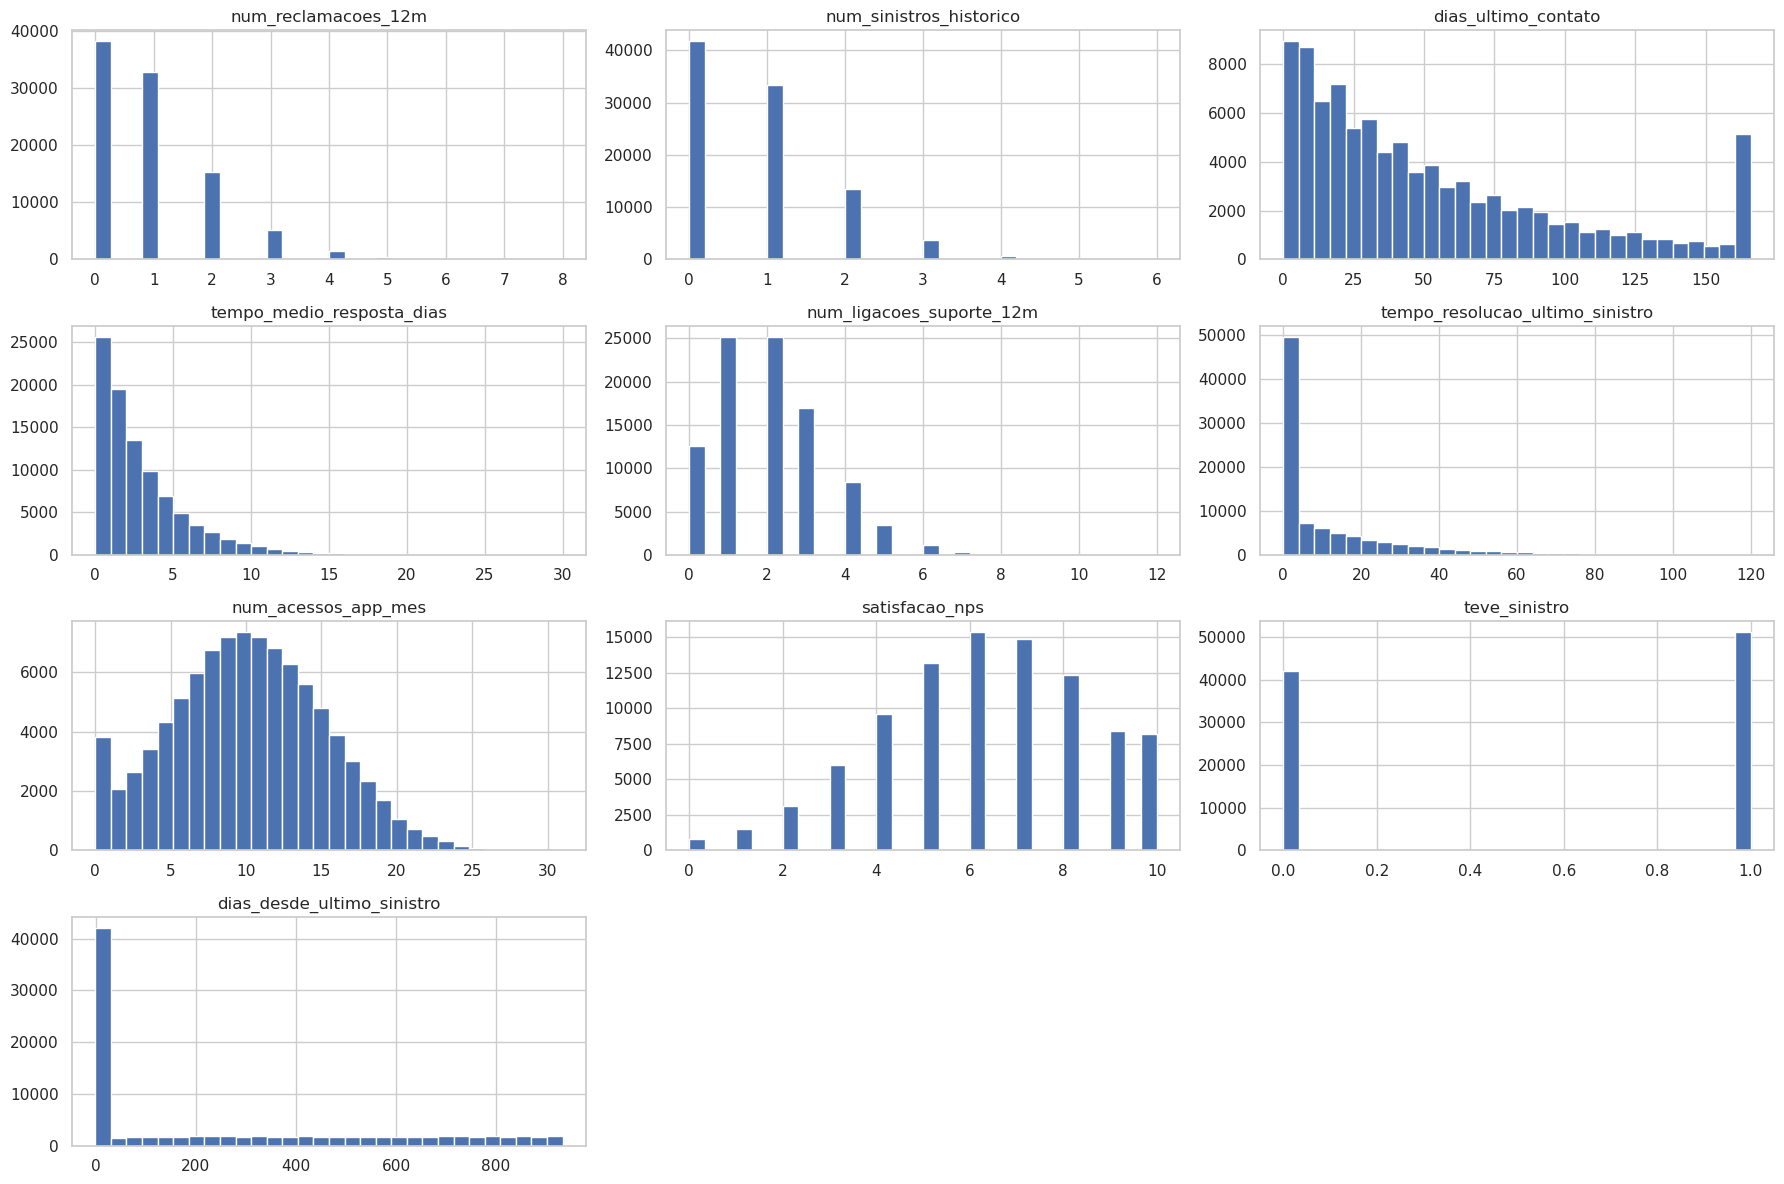

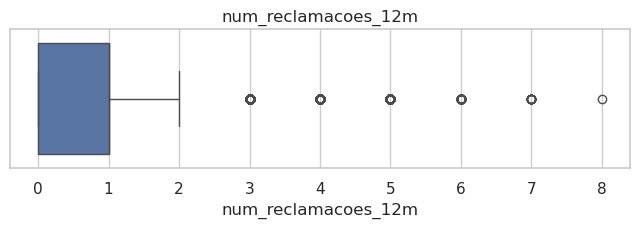

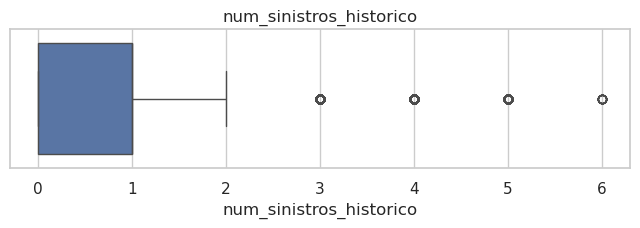

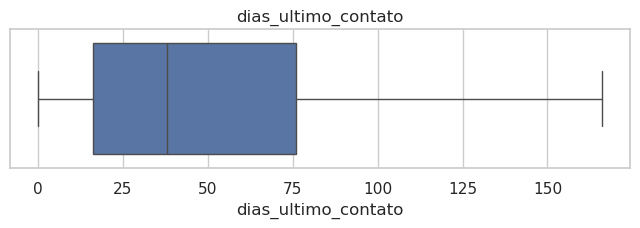

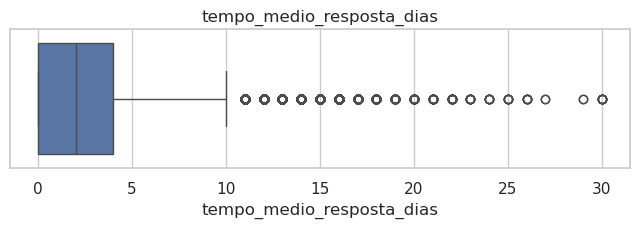

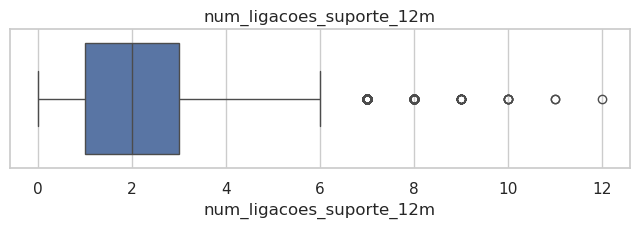

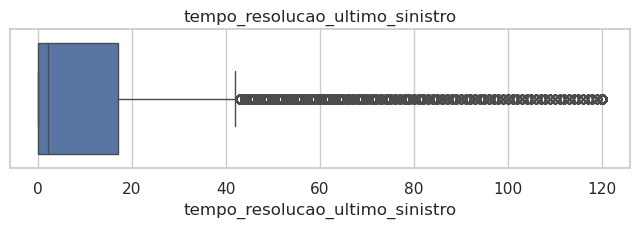

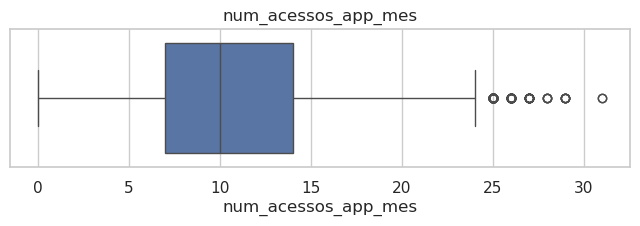

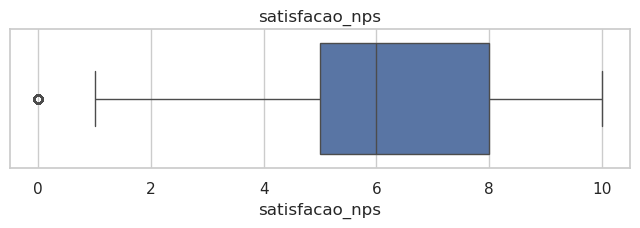

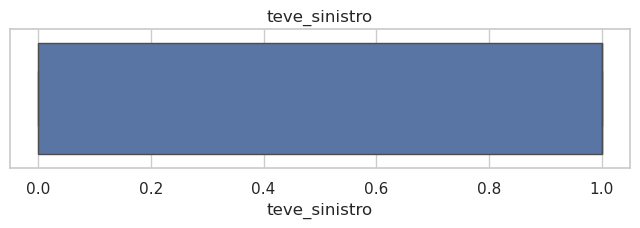

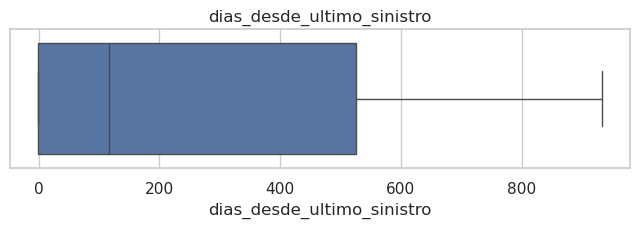


ASSIMETRIA


tempo_resolucao_ultimo_sinistro    2.328341
tempo_medio_resposta_dias          2.014233
num_reclamacoes_12m                1.162163
num_sinistros_historico            1.099064
dias_ultimo_contato                1.052159
dias_desde_ultimo_sinistro         0.724943
num_ligacoes_suporte_12m           0.715062
num_acessos_app_mes                0.094412
teve_sinistro                     -0.196495
satisfacao_nps                    -0.266146
dtype: float64

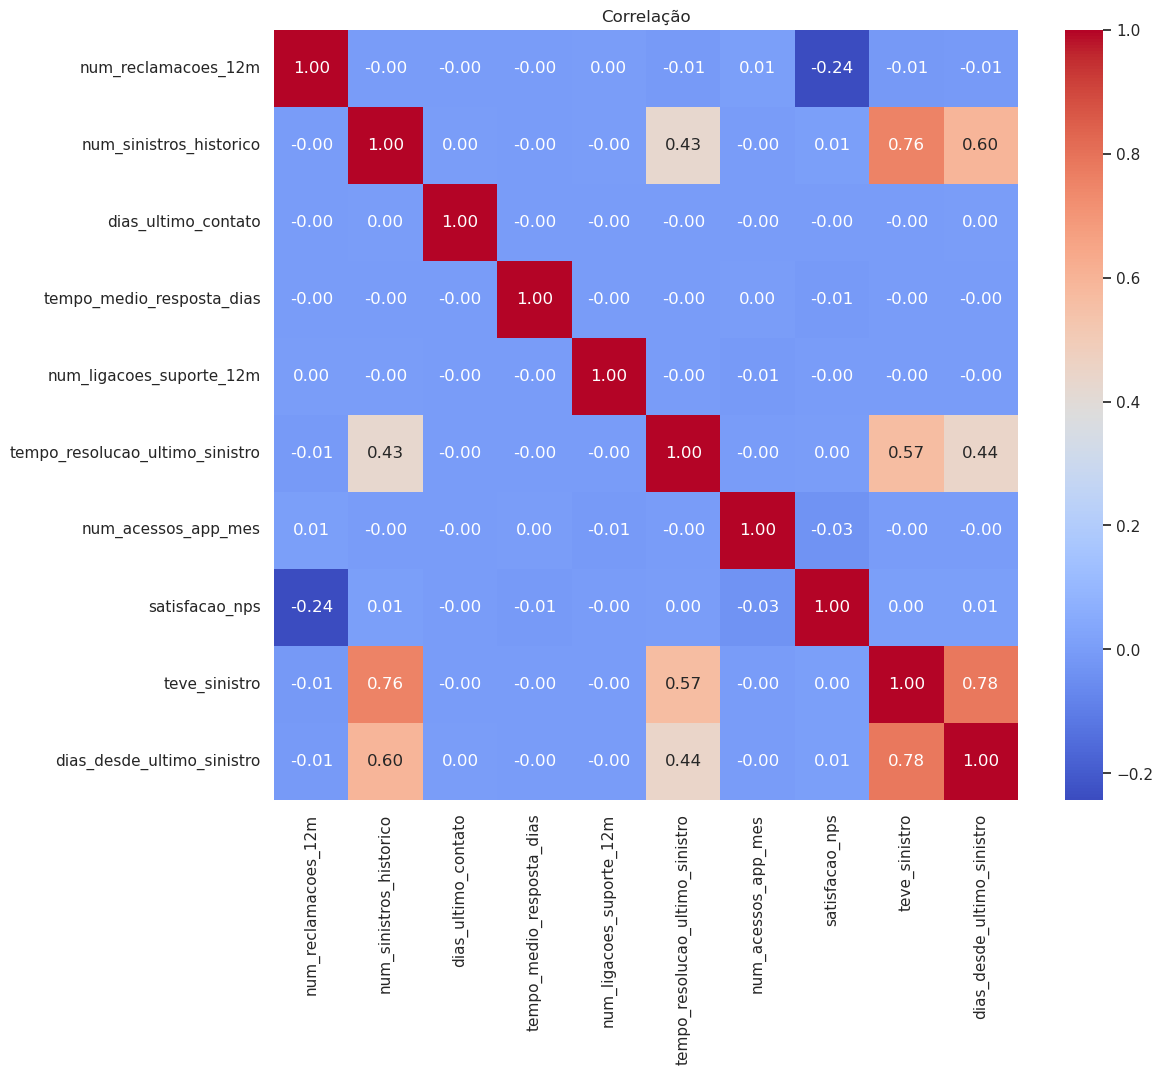


canal_preferencial_contato


canal_preferencial_contato
whatsapp    39210
email       28693
telefone    20642
carta        4587
Name: count, dtype: int64

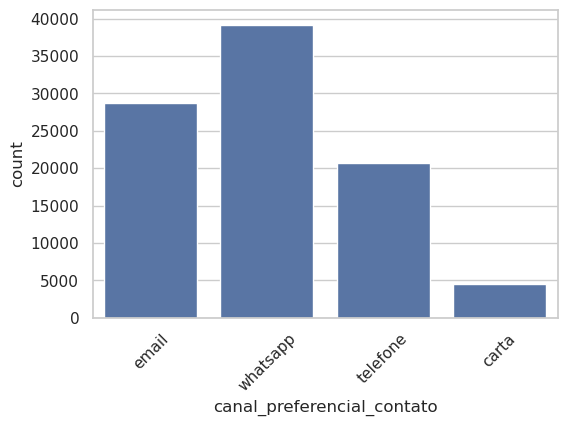


Dimensão após One-Hot Encoding: (93132, 13)


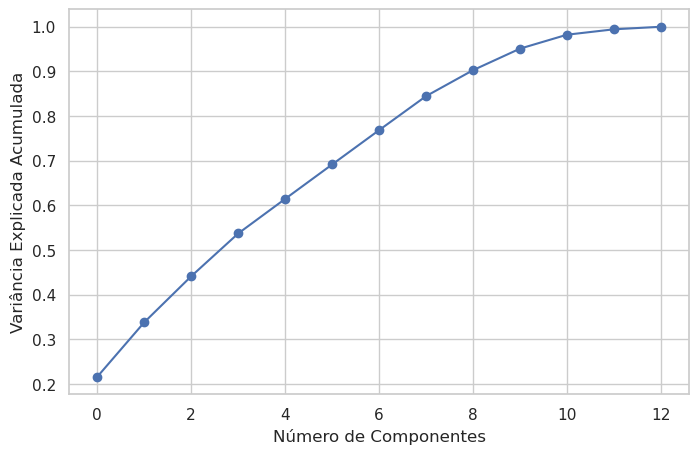

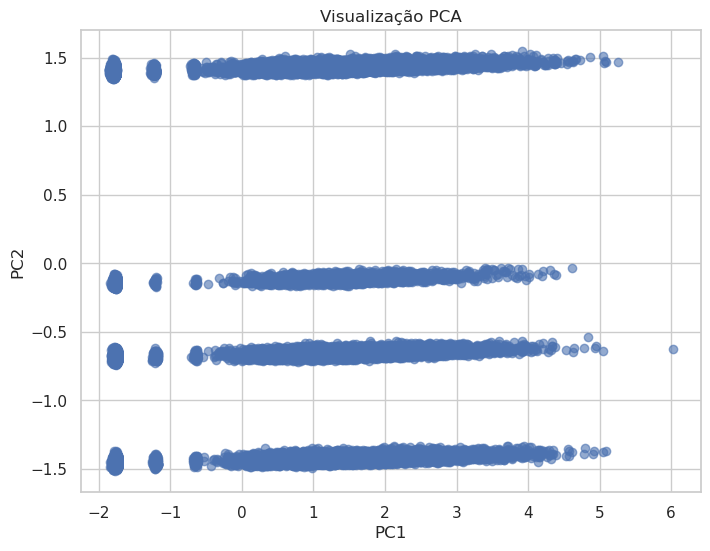

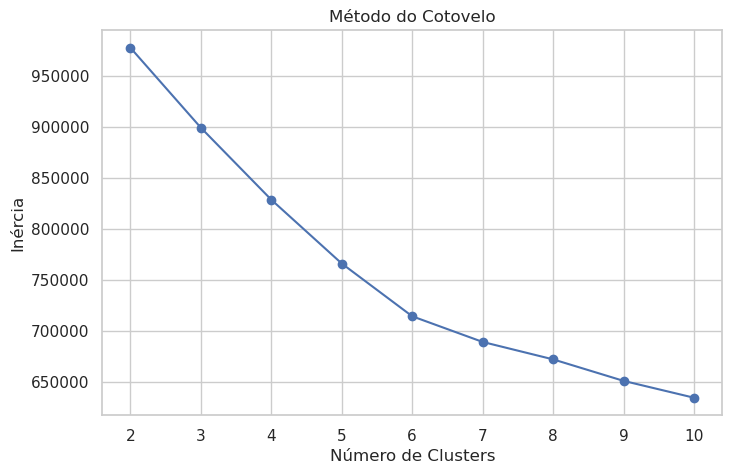

In [7]:
# ============================================================
# ANÁLISE EXPLORATÓRIA PARA CLUSTERIZAÇÃO
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

df = df_sinistros_tratado.copy()

# ============================================================
# Informações gerais
# ============================================================

print("="*60)
print("DIMENSÕES")
print(df.shape)

print("\nTIPOS DAS COLUNAS")
print(df.dtypes)

print("\nVALORES NULOS")
print(df.isnull().sum())

print("\nDUPLICATAS")
print(df.duplicated().sum())

# ============================================================
# Estatísticas descritivas
# ============================================================

print("\nESTATÍSTICAS")
display(df.describe(include='all').T)

# ============================================================
# Variáveis numéricas e categóricas
# ============================================================

num_cols = df.select_dtypes(include=np.number).columns.tolist()

cat_cols = df.select_dtypes(include='object').columns.tolist()

# Remove identificador
if 'id_cliente' in num_cols:
    num_cols.remove('id_cliente')

# ============================================================
# Histogramas
# ============================================================

df[num_cols].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()
plt.show()

# ============================================================
# Boxplots
# ============================================================

for coluna in num_cols:

    plt.figure(figsize=(8,1.8))

    sns.boxplot(
        x=df[coluna]
    )

    plt.title(coluna)

    plt.show()

# ============================================================
# Assimetria
# ============================================================

skewness = df[num_cols].skew().sort_values(ascending=False)

print("\nASSIMETRIA")
display(skewness)

# ============================================================
# Correlação
# ============================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlação")

plt.show()

# ============================================================
# Frequência das variáveis categóricas
# ============================================================

for coluna in cat_cols:

    print(f"\n{coluna}")

    display(df[coluna].value_counts())

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=coluna
    )

    plt.xticks(rotation=45)

    plt.show()

# ============================================================
# Padronização
# ============================================================

X = df.drop(columns=['id_cliente'])

X = pd.get_dummies(
    X,
    drop_first=True
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nDimensão após One-Hot Encoding:", X_scaled.shape)

# ============================================================
# PCA
# ============================================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

variancia = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(
    variancia,
    marker='o'
)

plt.xlabel("Número de Componentes")

plt.ylabel("Variância Explicada Acumulada")

plt.grid(True)

plt.show()

# ============================================================
# PCA em duas dimensões
# ============================================================

pca2 = PCA(n_components=2)

X2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X2[:,0],
    X2[:,1],
    alpha=0.6
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Visualização PCA")

plt.show()

# ============================================================
# Método do Cotovelo
# ============================================================

inercia = []

K = range(2,11)

for k in K:

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    modelo.fit(X_scaled)

    inercia.append(modelo.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    K,
    inercia,
    marker='o'
)

plt.xlabel("Número de Clusters")

plt.ylabel("Inércia")

plt.title("Método do Cotovelo")

plt.grid(True)

plt.show()

# ============================================================
# Silhouette Score
# ============================================================

scores = []

for k in range(2,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = modelo.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel("Número de Clusters")

plt.ylabel("Silhouette Score")

plt.title("Escolha do número de clusters")

plt.grid(True)

plt.show()

print("\nMelhor k:", np.argmax(scores)+2)
print("Maior Silhouette:", np.max(scores))

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Junta os dois datasets tratados pelo id_cliente
# ============================================================
df_full = df_cadastro_tratado.merge(
    df_sinistros_tratado, on='id_cliente', how='inner'
)
print(f"Linhas após merge: {len(df_full)}")

# ============================================================
# Seleciona colunas numéricas para visualizar
# (ajuste essa lista se quiser incluir/excluir alguma coluna)
# ============================================================
colunas_numericas = [
    'idade', 'renda_anual', 'valor_imovel', 'qtd_dependentes',
    'tempo_residencia_anos', 'num_reclamacoes_12m', 'num_sinistros_historico',
    'dias_ultimo_contato', 'tempo_medio_resposta_dias',
    'num_ligacoes_suporte_12m', 'num_acessos_app_mes', 'satisfacao_nps',
    'tempo_resolucao_ultimo_sinistro', 'dias_desde_ultimo_sinistro'
]
colunas_numericas = [c for c in colunas_numericas if c in df_full.columns]

# ============================================================
# Histogramas
# ============================================================
n = len(colunas_numericas)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    axes[i].hist(df_full[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuições — Histogramas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Boxplots
# ============================================================
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    axes[i].boxplot(df_full[col].dropna(), vert=True)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuições — Boxplots', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# VALIDAÇÃO — atendimento_sinistros.csv
# ============================================================

print("=" * 55)
print(f"Shape final: {df_sinistros_tratado.shape}")
print("=" * 55)

# 1. Nulos remanescentes
nulos = df_sinistros_tratado.isnull().sum()
print("\n── Nulos remanescentes ──")
print(nulos[nulos > 0] if nulos.any() else "Nenhum nulo ✅")

# 2. Missingness as a Feature
print("\n── Missingness as a Feature ──")
contagem = df_sinistros_tratado['teve_sinistro'].value_counts().rename({0: 'Sem sinistro', 1: 'Com sinistro'})
print(contagem)
print(f"\nClientes com teve_sinistro=0 e dias=-1: "
      f"{((df_sinistros_tratado['teve_sinistro']==0) & (df_sinistros_tratado['dias_desde_ultimo_sinistro']==-1)).sum()} ✅")
print(f"Clientes com teve_sinistro=1 e dias=-1 (erro): "
      f"{((df_sinistros_tratado['teve_sinistro']==1) & (df_sinistros_tratado['dias_desde_ultimo_sinistro']==-1)).sum()}")

# 3. Distribuição de dias por grupo
print("\n── dias_desde_ultimo_sinistro por grupo ──")
print(df_sinistros_tratado.groupby('teve_sinistro')['dias_desde_ultimo_sinistro'].describe().round(1))

# 4. Tipos
print("\n── Tipos das colunas ──")
print(df_sinistros_tratado.dtypes)

# 5. Duplicatas
print(f"\nDuplicatas em id_cliente: {df_sinistros_tratado['id_cliente'].duplicated().sum()}")

# 6. Amostra final
print("\n── Amostra (5 linhas) ──")
df_sinistros_tratado[['id_cliente', 'teve_sinistro', 'dias_desde_ultimo_sinistro',
                        'tempo_resolucao_ultimo_sinistro', 'satisfacao_nps']].sample(5)

In [8]:
df_cadastro_tratado.to_csv('/home/sagemaker-user/bases_tratadas/cadastro_tratado.csv', index=False)
df_sinistros_tratado.to_csv('/home/sagemaker-user/bases_tratadas/sinistros_tratado.csv', index=False)

In [8]:
import os
import pandas as pd

# 1. Definir o diretório das bases
diretorio = '/home/sagemaker-user/bases_tratadas'

# 2. Carregar os arquivos garantindo o tipo de dado da chave
def carregar_base(nome_arquivo):
    caminho_completo = os.path.join(diretorio, nome_arquivo)
    df = pd.read_csv(caminho_completo)
    
    # Garante que a chave de merge seja tratada como string para evitar erros
    if 'id_cliente' in df.columns:
        df['id_cliente'] = df['id_cliente'].astype(str).str.strip()
        
    return df

# Carregando cada uma das 5 bases
df_cadastro = carregar_base('cadastro_tratado.csv')
df_contratos = carregar_base('contratos_apolices_tratado.csv')
df_marketing = carregar_base('engajamento_marketing_tratado.csv')
df_sinistros = carregar_base('sinistros_tratado.csv')
df_churn = carregar_base('churn_.csv')

# 3. Executar o Merge Sequencial (Left Join)
df_final = df_cadastro \
    .merge(df_contratos, on='id_cliente', how='left') \
    .merge(df_marketing, on='id_cliente', how='left') \
    .merge(df_sinistros, on='id_cliente', how='left') \
    .merge(df_churn, on='id_cliente', how='left')

# 4. Verificação de Sucesso
print("--- Resumo do Merge ---")
print(f"Total de Clientes únicos (Cadastro): {df_cadastro['id_cliente'].nunique()}")
print(f"Total de Linhas na base final: {df_final.shape[0]}")
print(f"Total de Colunas na base final: {df_final.shape[1]}")

In [3]:
print((df_final.isnull().sum() / len(df_final) * 100).sort_values(ascending=False))

In [5]:
# Criando uma cópia para preservar a original
df_tratada = df_final.copy()

# Tratando colunas numéricas de contagem/valores
colunas_zerar = [
    'teve_sinistro', 'num_reclamacoes_12m', 'num_sinistros_historico', 
    'num_apolices_ativas', 'valor_premio_anual', 'num_produtos_contratados',
    'valor_cobertura_total', 'num_acessos_app_mes', 'num_ligacoes_suporte_12m'
]
df_tratada[colunas_zerar] = df_tratada[colunas_zerar].fillna(0)

# Tratando colunas categóricas (texto)
colunas_texto = ['tipo_cobertura', 'metodo_pagamento', 'canal_aquisicao', 'segmento_marketing', 'tipo_veiculo']
df_tratada[colunas_texto] = df_tratada[colunas_texto].fillna('Não Informado')

# Verificando se os principais alvos foram limpos
print(df_tratada[colunas_zerar + colunas_texto].isnull().sum())

In [6]:
# Criando uma tabela cruzada (proporção de churn por número de reclamações)
analise_reclamacoes = pd.crosstab(df_tratada['num_reclamacoes_12m'], df_tratada['churned'], normalize='index') * 100
print("--- % de Churn por Número de Reclamações nos últimos 12 meses ---")
print(analise_reclamacoes)

In [7]:
# Criando faixas etárias
df_tratada['faixa_etaria'] = pd.cut(df_tratada['idade'], bins=[0, 25, 35, 45, 55, 65, 100], 
                                    labels=['Até 25 anos', '26-35 anos', '36-45 anos', '46-55 anos', '56-65 anos', 'Mais de 65'])

# Calculando a taxa de churn por faixa
taxa_churn_idade = df_tratada.groupby('faixa_etaria')['churned'].mean() * 100
print(taxa_churn_idade)

In [14]:
# 1. Taxa de Churn por Número de Reclamações
print("--- Taxa de Churn por Volume de Reclamações (12 meses) ---")
taxa_reclamacoes = df_tratada.groupby('num_reclamacoes_12m')['churned'].mean() * 100
print(taxa_reclamacoes)

print("\n" + "="*50 + "\n")

# 2. Média de Ligações para o Suporte: Quem cancelou ligou mais?
print("--- Média de Ligações pro Suporte (12 meses) ---")
media_ligacoes = df_tratada.groupby('churned')['num_ligacoes_suporte_12m'].mean()
print(media_ligacoes)

--- Taxa de Churn por Volume de Reclamações (12 meses) ---
num_reclamacoes_12m
0.0     11.013888
1.0     12.081012
2.0     13.857703
3.0     15.122429
4.0     16.507001
5.0     15.186246
6.0     19.354839
7.0     23.076923
8.0    100.000000
Name: churned, dtype: float64


--- Média de Ligações pro Suporte (12 meses) ---
churned
0    1.864265
1    1.871005
Name: num_ligacoes_suporte_12m, dtype: float64


In [15]:
# Quem reclama mais tem sinistros mais lentos? (Média do tempo de resolução por nº de reclamações)
print("--- Tempo Médio de Resolução de Sinistro por Nº de Reclamações ---")
print(df_tratada.groupby('num_reclamacoes_12m')['tempo_resolucao_ultimo_sinistro'].mean())

print("\n" + "="*50 + "\n")

# O tipo de cobertura influi no volume de reclamações?
print("--- Média de Reclamações por Tipo de Cobertura ---")
print(df_tratada.groupby('tipo_cobertura')['num_reclamacoes_12m'].mean())

--- Tempo Médio de Resolução de Sinistro por Nº de Reclamações ---
num_reclamacoes_12m
0.0    11.884874
1.0    11.784512
2.0    11.568458
3.0    11.323213
4.0    11.234340
5.0    11.083095
6.0     9.306452
7.0    14.384615
8.0     0.000000
Name: tempo_resolucao_ultimo_sinistro, dtype: float64


--- Média de Reclamações por Tipo de Cobertura ---
tipo_cobertura
Básica           0.899949
Não Informado    0.882254
Padrão           0.865833
Plus             0.825268
Premium          0.813330
Name: num_reclamacoes_12m, dtype: float64


In [16]:
# 1. Churn vs Problemas de Pagamento
print("--- Taxa de Churn por Status de Pagamento ---")
print(df_tratada.groupby('pagamento_em_dia')['churned'].mean() * 100)

print("\n" + "="*50 + "\n")

# 2. O comportamento digital influencia? (Clientes que usam o app dão menos churn?)
print("--- Média de Acessos ao App por Status de Churn ---")
print(df_tratada.groupby('churned')['num_acessos_app_mes'].mean())

print("\n" + "="*50 + "\n")

# 3. Quem nunca logou tem mais propensão ao Churn?
print("--- Taxa de Churn por Status de Primeiro Login ('nunca_logou') ---")
print(df_tratada.groupby('nunca_logou')['churned'].mean() * 100)

--- Taxa de Churn por Status de Pagamento ---
pagamento_em_dia
0.0    17.954280
1.0    11.723829
Name: churned, dtype: float64


--- Média de Acessos ao App por Status de Churn ---
churned
0     9.49750
1    10.03496
Name: num_acessos_app_mes, dtype: float64


--- Taxa de Churn por Status de Primeiro Login ('nunca_logou') ---
nunca_logou
0.0    12.084261
1.0    11.868038
Name: churned, dtype: float64


In [17]:
import pandas as pd
import numpy as np

# Listando as colunas que pertencem à base de sinistros/suporte associado
colunas_sinistros = [
    'teve_sinistro', 
    'num_sinistros_historico', 
    'dias_desde_ultimo_sinistro', 
    'tempo_resolucao_ultimo_sinistro', 
    'satisfacao_nps'
]

print("======= ANÁLISE DE RELEVÂNCIA: BASE DE SINISTROS VS CHURN =======")

for col in colunas_sinistros:
    if col not in df_tratada.columns:
        continue
        
    print(f"\n➔ Avaliando a coluna: {col}")
    print("-" * 50)
    
    # Caso 1: Variáveis Categóricas ou Numéricas Discretas (Poucos valores únicos)
    if df_tratada[col].nunique() <= 10:
        # Gera a taxa de churn para cada categoria/valor
        tabela = df_tratada.groupby(col)['churned'].agg(
            Total_Clientes='count',
            Taxa_Churn_Pct=lambda x: round(x.mean() * 100, 2)
        ).reset_index()
        print(tabela.to_string(index=False))
        
        # Critério de relevância simples baseado na variação da taxa
        variacao = tabela['Taxa_Churn_Pct'].max() - tabela['Taxa_Churn_Pct'].min()
        if variacao > 5:
            print(f"💡 RELEVANTE: A taxa de churn varia {variacao:.2f}% dependendo do valor de '{col}'.")
        else:
            print(f"❌ POUCO RELEVANTE: A variação na taxa de churn é baixa ({variacao:.2f}%).")

    # Caso 2: Variáveis Numéricas Contínuas (Muitos valores únicos, ex: dias, tempo)
    else:
        # Como essas variáveis têm o '0' ou nulos de quem nunca teve sinistro, 
        # avaliamos a média/mediana APENAS de quem teve sinistro real para não distorcer.
        df_com_sinistro = df_tratada[df_tratada['teve_sinistro'] == 1]
        
        if len(df_com_sinistro) > 0:
            resumo_churn = df_com_sinistro.groupby('churned')[col].agg(
                Média='mean',
                Mediana='median',
                Mínimo='min',
                Máximo='max'
            ).reset_index()
            print("*(Análise aplicada apenas para clientes que tiveram sinistro real)*")
            print(resumo_churn.to_string(index=False))
            
            # Avalia a diferença percentual entre as médias de quem deu churn vs quem ficou
            media_0 = resumo_churn.loc[resumo_churn['churned'] == 0, 'Média'].values[0]
            media_1 = resumo_churn.loc[resumo_churn['churned'] == 1, 'Média'].values[0]
            
            if media_0 > 0:
                dif_percentual = abs((media_1 - media_0) / media_0) * 100
                if dif_percentual > 10: # Se houver mais de 10% de diferença entre os grupos
                    print(f"💡 RELEVANTE: Quem dá churn tem um comportamento substancialmente diferente em '{col}' (Diferença de {dif_percentual:.1f}% nas médias).")
                else:
                    print(f"❌ POUCO RELEVANTE: O comportamento médio de '{col}' é muito parecido entre quem fica e quem sai.")
            else:
                print("Não foi possível calcular a variação (média base é zero).")
        else:
            print("Sem dados suficientes de sinistros reais para avaliar esta coluna numérica contínua.")
            
    print("=" * 60)

======= ANÁLISE DE RELEVÂNCIA: BASE DE SINISTROS VS CHURN =======

➔ Avaliando a coluna: teve_sinistro
--------------------------------------------------
 teve_sinistro  Total_Clientes  Taxa_Churn_Pct
           0.0           48406           11.99
           1.0           50594           12.21
❌ POUCO RELEVANTE: A variação na taxa de churn é baixa (0.22%).

➔ Avaliando a coluna: num_sinistros_historico
--------------------------------------------------
 num_sinistros_historico  Total_Clientes  Taxa_Churn_Pct
                     0.0           48262           12.00
                     1.0           32861           12.15
                     2.0           13440           12.38
                     3.0            3621           11.88
                     4.0             693           12.99
                     5.0             111           13.51
                     6.0              12            8.33
💡 RELEVANTE: A taxa de churn varia 5.18% dependendo do valor de 'num_sinistros_historic

*(Análise aplicada apenas para clientes que tiveram sinistro real)*
 churned    Média  Mediana  Mínimo  Máximo
       0 6.389742      6.0     0.0    10.0
       1 5.231553      5.0     0.0    10.0
💡 RELEVANTE: Quem dá churn tem um comportamento substancialmente diferente em 'satisfacao_nps' (Diferença de 18.1% nas médias).


In [18]:
# 1. Cole aqui a lista de colunas que você extraiu da sua tabela de sinistros
colunas_reais_sinistros = list(df_sinistros_tratado.columns) 

# Garante que não vamos tentar avaliar a coluna 'id_cliente' ou 'churned' aqui dentro
if 'id_cliente' in colunas_reais_sinistros: colunas_reais_sinistros.remove('id_cliente')
if 'churned' in colunas_reais_sinistros: colunas_reais_sinistros.remove('churned')

print("======= ANÁLISE AUTOMATIZADA DA BASE DE SINISTROS =======")

for col in colunas_reais_sinistros:
    # Garante que a coluna existe na tabela final tratada
    if col not in df_tratada.columns:
        continue
        
    print(f"\n➔ Avaliando a coluna: {col}")
    print("-" * 50)
    
    # Se for categórica ou discreta (poucos valores únicos)
    if df_tratada[col].nunique() <= 12:
        tabela = df_tratada.groupby(col)['churned'].agg(
            Total_Clientes='count',
            Taxa_Churn_Pct=lambda x: round(x.mean() * 100, 2)
        ).reset_index()
        print(tabela.to_string(index=False))
        
    # Se for numérica contínua (muitos valores únicos)
    else:
        # Filtra quem tem valores válidos (maiores que zero) para não distorcer a média
        df_valido = df_tratada[df_tratada[col] > 0]
        
        resumo_churn = df_valido.groupby('churned')[col].agg(
            Média='mean',
            Mediana='median',
            Mínimo='min',
            Máximo='max'
        ).reset_index()
        print(resumo_churn.to_string(index=False))
    print("=" * 60)

======= ANÁLISE AUTOMATIZADA DA BASE DE SINISTROS =======

➔ Avaliando a coluna: num_reclamacoes_12m
--------------------------------------------------


 num_reclamacoes_12m  Total_Clientes  Taxa_Churn_Pct
                 0.0           44571           11.01
                 1.0           32489           12.08
                 2.0           15053           13.86
                 3.0            5105           15.12
                 4.0            1357           16.51
                 5.0             349           15.19
                 6.0              62           19.35
                 7.0              13           23.08
                 8.0               1          100.00

➔ Avaliando a coluna: num_sinistros_historico
--------------------------------------------------


 num_sinistros_historico  Total_Clientes  Taxa_Churn_Pct
                     0.0           48262           12.00
                     1.0           32861           12.15
                     2.0           13440           12.38
                     3.0            3621           11.88
                     4.0             693           12.99
                     5.0             111           13.51
                     6.0              12            8.33



➔ Avaliando a coluna: dias_ultimo_contato
--------------------------------------------------


 churned     Média  Mediana  Mínimo  Máximo
       0 52.407076     38.0     1.0   166.0
       1 53.039068     39.0     1.0   166.0

➔ Avaliando a coluna: canal_preferencial_contato
--------------------------------------------------


canal_preferencial_contato  Total_Clientes  Taxa_Churn_Pct
                     carta            4522           11.63
                     email           28476           12.14
                  telefone           20372           12.19
                  whatsapp           38835           12.13

➔ Avaliando a coluna: tempo_medio_resposta_dias
--------------------------------------------------
 churned    Média  Mediana  Mínimo  Máximo
       0 3.530729      3.0     1.0    30.0
       1 3.521262      3.0     1.0    30.0

➔ Avaliando a coluna: num_ligacoes_suporte_12m
--------------------------------------------------


 churned    Média  Mediana  Mínimo  Máximo
       0 2.314307      2.0     1.0    12.0
       1 2.311753      2.0     1.0     9.0

➔ Avaliando a coluna: tempo_resolucao_ultimo_sinistro
--------------------------------------------------
 churned     Média  Mediana  Mínimo  Máximo
       0 22.006307     15.0     1.0   120.0
       1 21.800731     15.0     1.0   120.0

➔ Avaliando a coluna: num_acessos_app_mes
--------------------------------------------------


 churned     Média  Mediana  Mínimo  Máximo
       0 10.476858     10.0     1.0    31.0
       1 10.975452     11.0     1.0    27.0

➔ Avaliando a coluna: satisfacao_nps
--------------------------------------------------
 satisfacao_nps  Total_Clientes  Taxa_Churn_Pct
            0.0             786           32.70
            1.0            1471           28.14
            2.0            3104           24.77
            3.0            5929           19.73
            4.0            9466           16.42
            5.0           13055           14.37
            6.0           15191           11.91
            7.0           14644            9.93
            8.0           12168            7.76
            9.0            8293            6.05
           10.0            8098            5.27

➔ Avaliando a coluna: teve_sinistro
--------------------------------------------------
 teve_sinistro  Total_Clientes  Taxa_Churn_Pct
           0.0           48406           11.99
           1.0       

In [41]:
df_tratada.to_csv('base_completa_churn.csv', index=False)
print("Arquivo salvo com sucesso no seu diretório atual!")

Arquivo salvo com sucesso no seu diretório atual!


In [16]:
import pandas as pd
import numpy as np

# 1. Criando faixas de idade puras para o teste (Jovem, Adulto, Sênior)
df_tratada['faixa_idade_teste'] = pd.cut(
    df_tratada['idade'], 
    bins=[0, 30, 50, 100], 
    labels=['Até 30 anos (Jovens)', '31 a 50 anos (Adultos)', 'Acima de 50 anos (Sêniores)']
)

# 2. Cruzando a Idade com o Estado Civil para ver a taxa de Churn
print("======= PROVA REAL: IMPACTO DA IDADE CONTROLADO POR ESTADO CIVIL =======")
provada_idade = df_tratada.groupby(['estado_civil', 'faixa_idade_teste'], observed=False)['churned'].agg(
    Total_Clientes='count',
    Taxa_Churn_Pct=lambda x: round(x.mean() * 100, 2)
).reset_index()

print(provada_idade.to_string(index=False))
print("=" * 72)

# 3. Limpando a coluna de teste
df_tratada.drop(columns=['faixa_idade_teste'], inplace= False)

======= PROVA REAL: IMPACTO DA IDADE CONTROLADO POR ESTADO CIVIL =======
estado_civil           faixa_idade_teste  Total_Clientes  Taxa_Churn_Pct
      casado        Até 30 anos (Jovens)            7257           10.82
      casado      31 a 50 anos (Adultos)           30961            8.68
      casado Acima de 50 anos (Sêniores)           18048            6.45
    solteiro        Até 30 anos (Jovens)            7427           18.86
    solteiro      31 a 50 anos (Adultos)           24708           17.77
    solteiro Acima de 50 anos (Sêniores)           10599           14.69


,id_cliente,idade,genero,estado_civil,tem_filhos,qtd_dependentes,escolaridade,renda_anual,possui_imovel,valor_imovel,tempo_residencia_anos,num_apolices_ativas,tipo_cobertura,valor_premio_anual,tempo_cliente_dias,data_primeira_apolice,num_produtos_contratados,valor_cobertura_total,franquia_media,canal_aquisicao,pagamento_em_dia,desconto_aplicado_pct,metodo_pagamento,score_engajamento_digital,indicou_clientes,renovacoes_consecutivas,indice_relacionamento,tipo_veiculo,ano_veiculo,km_anual_estimado,segmento_marketing,regiao_vendas,ultimo_login_portal_dias,score_propensao_churn,cluster_sugerido_crm,nunca_logou,num_reclamacoes_12m,num_sinistros_historico,dias_ultimo_contato,canal_preferencial_contato,tempo_medio_resposta_dias,num_ligacoes_suporte_12m,tempo_resolucao_ultimo_sinistro,num_acessos_app_mes,satisfacao_nps,teve_sinistro,dias_desde_ultimo_sinistro,churned,faixa_etaria
0,221300612846,42,M,solteiro,0,0,Medio,33700.0,1,178000.0,3,3.0,Padrão,2244.78,2621.0,2019-03-29,1.0,137668.1900,896.79,Telefone,1.0,14.5,Pix,67.0,0.0,6.0,64.4,Carro,2017.0,18000.0,Ouro,Centro-Oeste,31.0,0.2292,3.0,1.0,0.0,1.0,35.0,email,1.0,1.0,25.0,8.0,6.0,1.0,628.0,0,36-45 anos
1,221301580435,41,M,solteiro,1,2,Superior,49400.0,1,353000.0,11,2.0,Padrão,801.89,3062.0,2018-01-12,1.0,128280.0000,784.98,Digital,1.0,13.1,Debito,51.0,0.0,8.0,93.0,Suv,2015.0,18400.0,Bronze,Nordeste,12.0,0.5690,2.0,0.0,0.0,0.0,1.0,telefone,11.0,1.0,0.0,13.0,10.0,0.0,-1.0,0,36-45 anos
2,221302524584,36,M,casado,0,0,Superior,37100.0,1,261000.0,4,2.0,Básica,748.93,2004.0,2020-12-05,2.0,181655.2800,764.19,Digital,1.0,6.8,Cartao,36.0,0.0,4.0,28.0,Carro,2010.0,18400.0,Prata,Sul,31.0,0.9459,5.0,1.0,3.0,2.0,70.0,whatsapp,3.0,1.0,21.0,4.0,2.0,1.0,335.0,0,36-45 anos
3,221302410745,51,F,casado,0,0,Medio,72400.0,1,292000.0,5,0.0,Não Informado,0.00,NaN,NaN,0.0,0.0000,NaN,Não Informado,NaN,NaN,Não Informado,NaN,NaN,NaN,NaN,Não Informado,NaN,NaN,Não Informado,NaN,NaN,NaN,NaN,NaN,1.0,1.0,64.0,whatsapp,1.0,3.0,25.0,3.0,7.0,1.0,467.0,0,46-55 anos
4,221301055649,18,F,solteiro,0,0,Medio,40500.0,1,362000.0,7,4.0,Padrão,1113.14,1725.0,2021-09-10,1.0,119616.4000,1066.00,Digital,1.0,18.6,Debito,46.0,0.0,7.0,47.6,Moto,2016.0,11200.0,Bronze,Sudeste,46.0,0.5016,1.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0,Até 25 anos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98995,221302089286,42,F,casado,0,0,Medio,84400.0,1,345000.0,3,1.0,Premium,1255.38,4273.0,2014-09-19,5.0,212398.3000,1021.30,Agente,1.0,8.9,Debito,62.0,0.0,11.0,58.5,Carro,2005.0,22600.0,Bronze,Centro-Oeste,24.0,0.8628,2.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0,36-45 anos
98996,221303133991,39,M,solteiro,1,2,Superior,62500.0,1,306000.0,5,3.0,Padrão,1454.52,1603.0,2022-01-10,2.0,263912.1425,960.01,Agente,0.0,12.0,Debito,51.0,0.0,6.0,84.8,Moto,2005.0,21000.0,Prata,Centro-Oeste,40.0,0.5016,2.0,0.0,0.0,0.0,128.0,email,4.0,3.0,0.0,4.0,6.0,0.0,-1.0,0,36-45 anos
98997,221302639324,31,F,solteiro,1,2,Pos,73100.0,1,368000.0,2,4.0,Básica,1556.86,30.0,2026-05-02,1.0,133234.2000,1518.66,Indicacao,1.0,15.0,Cartao,53.0,0.0,2.0,55.8,Pickup,2015.0,22500.0,Bronze,Centro-Oeste,34.0,0.9252,3.0,0.0,1.0,2.0,72.0,email,5.0,1.0,2.0,10.0,6.0,1.0,11.0,1,26-35 anos
98998,221302280364,44,F,casado,0,0,Medio,56000.0,1,346000.0,3,1.0,Padrão,1310.00,3321.0,2017-04-28,5.0,137668.1900,1209.32,Agente,1.0,0.3,Boleto,7.0,0.0,12.0,66.6,Suv,2017.0,15500.0,Ouro,Sudeste,7.0,0.3124,4.0,0.0,0.0,0.0,50.0,telefone,5.0,0.0,0.0,3.0,8.0,0.0,-1.0,0,36-45 anos


Gerando o Pairplot... Isso pode levar alguns segundos.


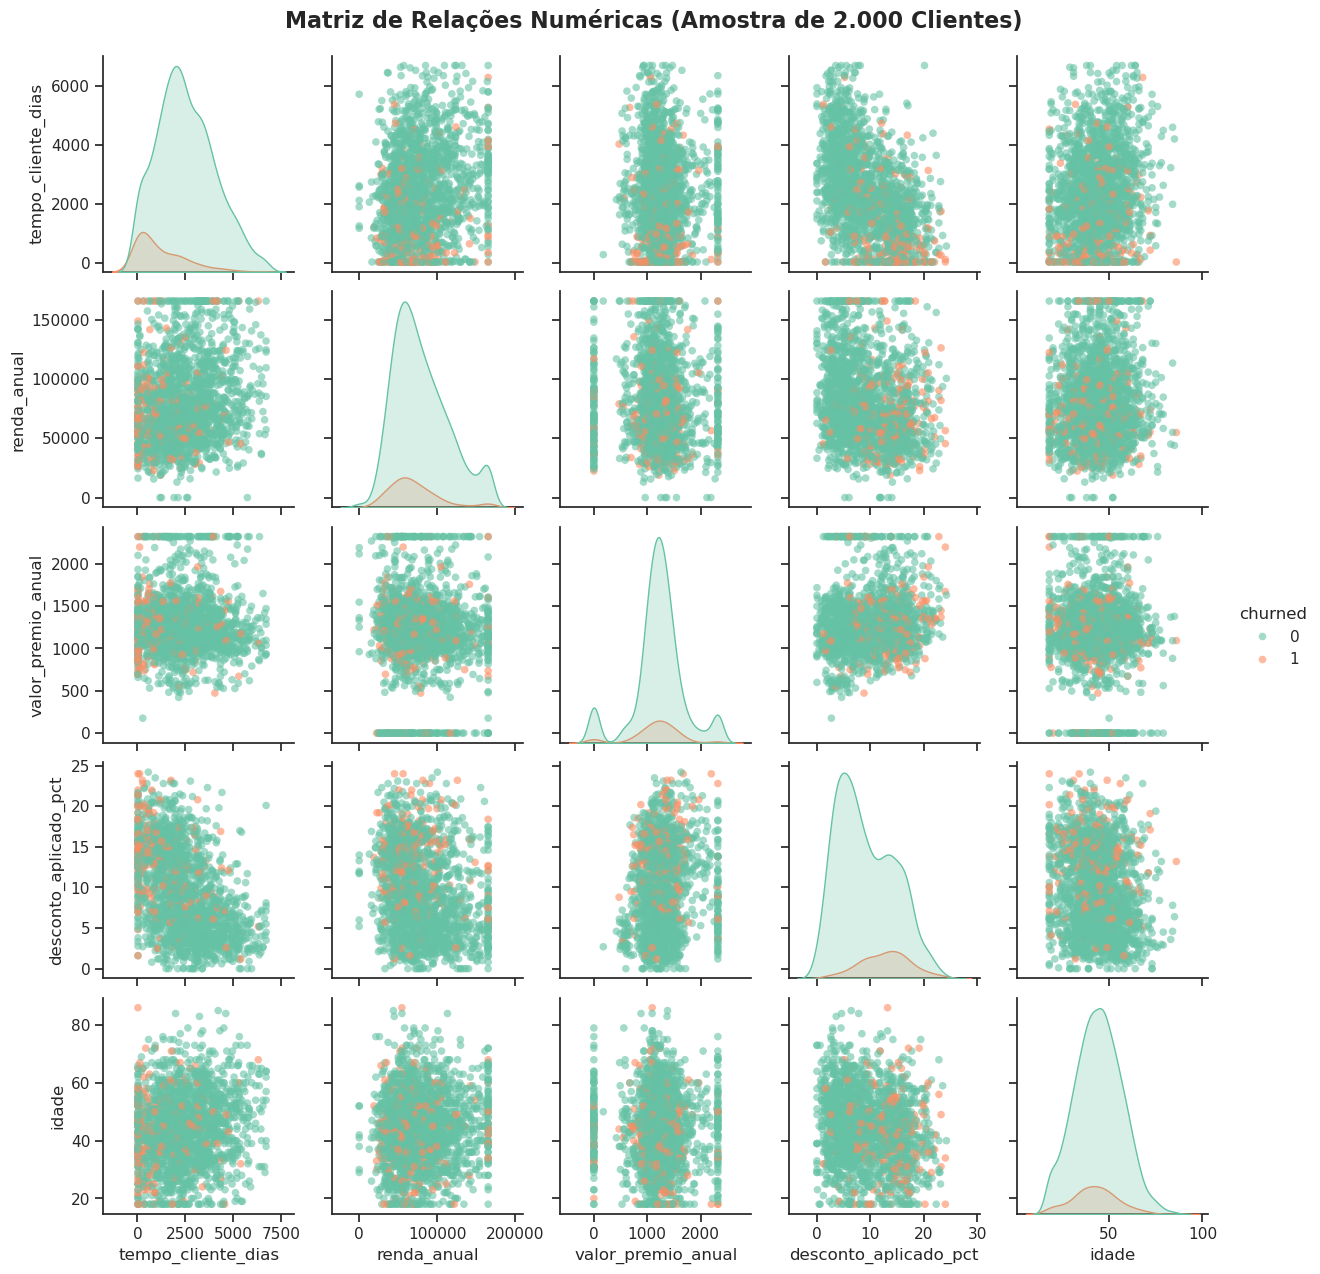

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selecionando as variáveis numéricas mais fortes que descobrimos
# Deixei 'idade' e 'renda_anual' para você ver visualmente como elas se comportam
colunas_numericas = [
    'tempo_cliente_dias', 
    'renda_anual', 
    'valor_premio_anual', 
    'desconto_aplicado_pct',
    'idade'
]

# 2. Criando o Pairplot com uma amostra para rodar rápido e leve
# O parâmetro 'hue' vai colorir os pontos: Azul para quem ficou (0) e Laranja/Vermelho para Churn (1)
print("Gerando o Pairplot... Isso pode levar alguns segundos.")

sns.set_theme(style="ticks")
g = sns.pairplot(
    data=df_tratada.sample(n=2000, random_state=42), 
    vars=colunas_numericas, 
    hue='churned', 
    palette='Set2',
    diag_kind='kde', # Mostra as curvas de densidade na diagonal
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'none'} # Deixa os pontos levemente transparentes
)

# Ajustando títulos para ficar elegante
g.fig.suptitle('Matriz de Relações Numéricas (Amostra de 2.000 Clientes)', fontweight='bold', fontsize=16, y=1.02)
plt.show()

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split  # <-- Corrigido aqui!
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================================================================
# 1. SELEÇÃO DE FEATURES (Filtradas pelo nosso Raio-X)
# ===========================================================================
features_selecionadas = [
    'tempo_cliente_dias', 'num_produtos_contratados', 'satisfacao_nps',
    'num_apolices_ativas', 'valor_cobertura_total', 'renovacoes_consecutivas',
    'valor_premio_anual', 'desconto_aplicado_pct', 'estado_civil', 'num_reclamacoes_12m'
]

# ATENÇÃO: Se o seu DataFrame tiver outro nome, altere 'df_tratada' abaixo:
X = df_tratada[features_selecionadas].copy()
y = df_tratada['churned']

# Tratando os nulos residuais que vimos no tempo_cliente_dias
if X['tempo_cliente_dias'].isna().sum() > 0:
    X['tempo_cliente_dias'] = X['tempo_cliente_dias'].fillna(X['tempo_cliente_dias'].median())

# ===========================================================================
# 2. TRATAMENTO DE TEXTO (One-Hot Encoding para variáveis categóricas)
# ===========================================================================
X = pd.get_dummies(X, columns=['estado_civil'], drop_first=True)

# ===========================================================================
# 3. DIVISÃO EM TREINO E TESTE (75% Treino / 25% Teste)
# ===========================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ===========================================================================
# 4. TREINAMENTO DO MODELO (Random Forest com Ajuste de Peso)
# ===========================================================================
print("Treinando o modelo preditivo corrigido... Por favor, aguarde.")

# Adicionamos class_weight='balanced' para forçar o modelo a caçar o Churn
modelo_churn = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', # <-- O segredo está aqui!
    random_state=42, 
    n_jobs=-1
)
modelo_churn.fit(X_train, y_train)
# ===========================================================================
# 5. AVALIAÇÃO DE PERFORMANCE
# ===========================================================================
y_pred = modelo_churn.predict(X_test)
y_probs = modelo_churn.predict_proba(X_test)[:, 1]

print("\n================ RELATÓRIO DE PERFORMANCE ================")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

# Plota a Matriz de Confusão para ver erros e acertos reais
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Ficou (0)', 'Churn (1)'], yticklabels=['Ficou (0)', 'Churn (1)'])
plt.title('Matriz de Confusão (Erros vs Acertos do Modelo)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Realidade do Cliente')
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ===========================================================================
# 1. LIMPEZA E TRATAMENTO DE NULOS CRÍTICOS
# ===========================================================================
df_ml = df_tratada.copy()

# Removendo o ID para evitar Overfitting
if 'id_cliente' in df_ml.columns:
    df_ml.drop(columns=['id_cliente'], inplace=True)

# Tratamentos específicos de nulos baseados nas regras de negócio
df_ml['pagamento_em_dia'] = df_ml['pagamento_em_dia'].fillna(0)
df_ml['indicou_clientes'] = df_ml['indicou_clientes'].fillna(0)
df_ml['nunca_logou'] = df_ml['nunca_logou'].fillna(0)
df_ml['dias_desde_ultimo_sinistro'] = df_ml['dias_desde_ultimo_sinistro'].fillna(9999)

# Preenchendo as demais colunas numéricas com suas respectivas medianas
colunas_numericas_com_nulos = df_ml.select_dtypes(include=[np.number]).columns
for col in colunas_numericas_com_nulos:
    if df_ml[col].isna().sum() > 0:
        df_ml[col] = df_ml[col].fillna(df_ml[col].median())

# Preenchendo coluna de texto faltante (Região e Canal de contato) com 'Desconhecido'
df_ml['regiao_vendas'] = df_ml['regiao_vendas'].fillna('Desconhecido')
df_ml['canal_preferencial_contato'] = df_ml['canal_preferencial_contato'].fillna('Desconhecido')

# ===========================================================================
# 2. ENCODING (Transformar todo o texto em número)
# ===========================================================================
colunas_categoricas = [
    'genero', 'estado_civil', 'escolaridade', 'tipo_cobertura', 
    'canal_aquisicao', 'metodo_pagamento', 'tipo_veiculo', 
    'segmento_marketing', 'regiao_vendas', 'canal_preferencial_contato'
]

# get_dummies resolve todas de uma vez só!
df_final_modelagem = pd.get_dummies(df_ml, columns=colunas_categoricas, drop_first=True)

# Garantindo que a faixa_etaria (que era category) não entre como ruído
if 'faixa_etaria' in df_final_modelagem.columns:
    df_final_modelagem.drop(columns=['faixa_etaria'], inplace=True)

# ===========================================================================
# 3. SEPARAÇÃO E TREINAMENTO
# ===========================================================================
X = df_final_modelagem.drop(columns=['churned'])
y = df_final_modelagem['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Treinando Super Modelo com {X_train.shape[1]} variáveis explicativas...")

# Mantendo o class_weight='balanced' para combater o desbalanceamento
super_modelo = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
super_modelo.fit(X_train, y_train)

# ===========================================================================
# 4. AVALIAÇÃO DO NOVO THRESHOLD OTIMIZADO
# ===========================================================================
y_probs = super_modelo.predict_proba(X_test)[:, 1]

# Vamos aplicar o threshold de 60% que tinha se mostrado promissor
threshold_escolhido = 0.60
y_pred_final = (y_probs >= threshold_escolhido).astype(int)

print("\n================ NOVO RELATÓRIO DE PERFORMANCE GLOBALL ================")
print(classification_report(y_test, y_pred_final))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

In [30]:
# Escaneando novos thresholds para a base completa
for ts in [0.45, 0.50, 0.55, 0.60]:
    preds = (y_probs >= ts).astype(int)
    cm_ts = confusion_matrix(y_test, preds)
    
    precision_1 = cm_ts[1, 1] / (cm_ts[1, 1] + cm_ts[0, 1]) if (cm_ts[1, 1] + cm_ts[0, 1]) > 0 else 0
    recall_1 = cm_ts[1, 1] / (cm_ts[1, 1] + cm_ts[1, 0])
    
    print(f"Threshold: {ts*100:.0f}% | Precisão: {precision_1*100:.1f}% | Recall: {recall_1*100:.1f}% | Clientes Salvos: {cm_ts[1, 1]}")

Threshold: 45% | Precisão: 31.1% | Recall: 70.7% | Clientes Salvos: 2117
Threshold: 50% | Precisão: 34.8% | Recall: 63.5% | Clientes Salvos: 1903
Threshold: 55% | Precisão: 38.8% | Recall: 56.6% | Clientes Salvos: 1695
Threshold: 60% | Precisão: 42.8% | Recall: 50.7% | Clientes Salvos: 1519


/tmp/ipykernel_625/2801338326.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia.head(12), palette='viridis')


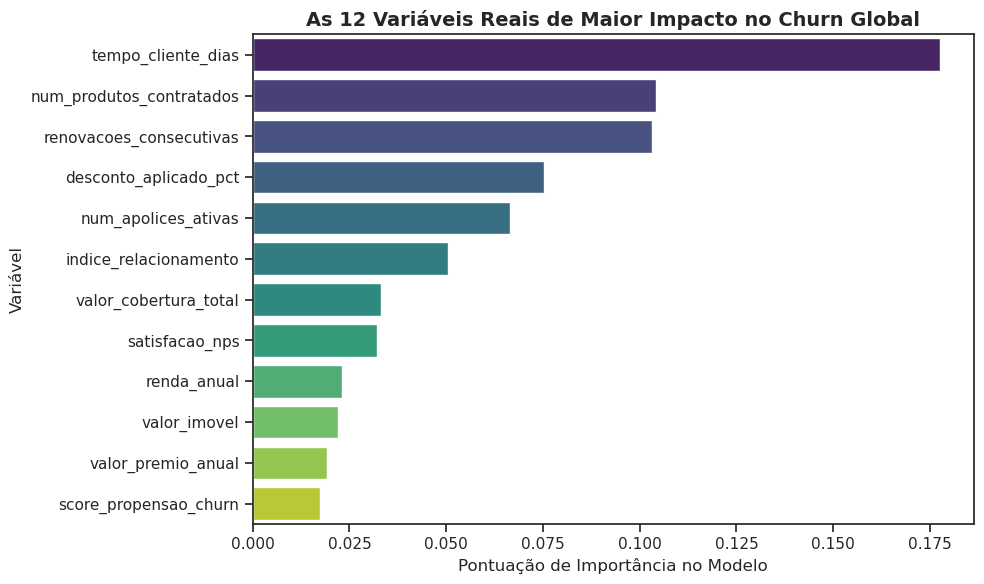

In [31]:
# Extraindo as variáveis mais importantes do super modelo
importâncias = super_modelo.feature_importances_
df_importancia = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia': importâncias
}).sort_values(by='Importancia', ascending=False)

# Mostrando as 12 variáveis mais brutas do modelo inteiro
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=df_importancia.head(12), palette='viridis')
plt.title('As 12 Variáveis Reais de Maior Impacto no Churn Global', fontweight='bold', fontsize=14)
plt.xlabel('Pontuação de Importância no Modelo')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

In [28]:
# Excluir clientes com nulos nas bases de sinistros, contratos ou marketing
colunas_referencia = ['teve_sinistro', 'num_apolices_ativas', 'segmento_marketing']

antes = df_final.shape[0]
df_final = df_final.dropna(subset=colunas_referencia)
depois = df_final.shape[0]

print(f"Linhas antes: {antes}")
print(f"Linhas depois: {depois}")
print(f"Removidas: {antes - depois} ({(antes-depois)/antes*100:.1f}%)")

# Confirmar zero nulos
print(f"\nNulos remanescentes:\n{df_final.isnull().sum()[df_final.isnull().sum() > 0]}")

# Checar se a taxa de churn geral mudou muito
print(f"\nTaxa de churn após exclusão: {df_final['churned'].mean()*100:.2f}%")

Linhas antes: 99000
Linhas depois: 82356
Removidas: 16644 (16.8%)

Nulos remanescentes:
Series([], dtype: int64)

Taxa de churn após exclusão: 12.10%


In [29]:
import numpy as np

# ── Identificar colunas novas (contratos + marketing) ──────────────────
cols_contratos = ['num_apolices_ativas', 'tipo_cobertura', 'valor_premio_anual',
                   'tempo_cliente_dias', 'desconto_aplicado_pct', 'metodo_pagamento',
                   'franquia_media', 'num_produtos_contratados', 'pagamento_em_dia',
                   'valor_cobertura_total', 'canal_aquisicao']

cols_marketing = ['regiao_vendas', 'score_engajamento_digital', 'segmento_marketing',
                   'km_anual_estimado', 'ano_veiculo', 'tipo_veiculo',
                   'indice_relacionamento', 'renovacoes_consecutivas', 'indicou_clientes',
                   'ultimo_login_portal_dias', 'nunca_logou']

cols_novas = cols_contratos + cols_marketing

# ── Separar por tipo ─────────────────────────────────────────────────
cols_numericas = [c for c in cols_novas if df_final[c].dtype in ['int64', 'float64']]
cols_categoricas = [c for c in cols_novas if df_final[c].dtype == 'object']

print(f"Numéricas ({len(cols_numericas)}): {cols_numericas}")
print(f"Categóricas ({len(cols_categoricas)}): {cols_categoricas}")

Numéricas (16): ['num_apolices_ativas', 'valor_premio_anual', 'tempo_cliente_dias', 'desconto_aplicado_pct', 'franquia_media', 'num_produtos_contratados', 'pagamento_em_dia', 'valor_cobertura_total', 'score_engajamento_digital', 'km_anual_estimado', 'ano_veiculo', 'indice_relacionamento', 'renovacoes_consecutivas', 'indicou_clientes', 'ultimo_login_portal_dias', 'nunca_logou']
Categóricas (6): ['tipo_cobertura', 'metodo_pagamento', 'canal_aquisicao', 'regiao_vendas', 'segmento_marketing', 'tipo_veiculo']


In [30]:
# ── Numéricas: correlação com churned + comparação de médias ───────────
print("=" * 70)
print("VARIÁVEIS NUMÉRICAS — poder preditivo")
print("=" * 70)

resultado_num = []
for col in cols_numericas:
    corr = df_final[col].corr(df_final['churned'])
    media_churn = df_final.loc[df_final['churned'] == 1, col].mean()
    media_ativo = df_final.loc[df_final['churned'] == 0, col].mean()
    resultado_num.append({
        'variavel': col,
        'correlacao': round(corr, 3),
        'media_churn': round(media_churn, 2),
        'media_ativo': round(media_ativo, 2),
        'diff_pct': round((media_churn - media_ativo) / media_ativo * 100, 1) if media_ativo != 0 else np.nan
    })

df_resultado_num = pd.DataFrame(resultado_num).sort_values('correlacao', key=abs, ascending=False)
print(df_resultado_num.to_string(index=False))

VARIÁVEIS NUMÉRICAS — poder preditivo
                 variavel  correlacao  media_churn  media_ativo  diff_pct
       tempo_cliente_dias      -0.298      1141.03      2532.28     -54.9
  renovacoes_consecutivas      -0.270         3.04         6.56     -53.6
      num_apolices_ativas       0.241         3.24         2.30      40.5
 num_produtos_contratados      -0.232         1.38         2.47     -44.0
    desconto_aplicado_pct       0.224        12.95         9.22      40.4
    indice_relacionamento      -0.187        45.07        55.23     -18.4
    valor_cobertura_total      -0.096    132212.11    145188.32      -8.9
score_engajamento_digital       0.050        53.76        50.70       6.0
         pagamento_em_dia      -0.047         0.90         0.94      -3.7
         indicou_clientes      -0.026         0.12         0.14     -19.2
       valor_premio_anual       0.017      1302.22      1283.63       1.4
           franquia_media       0.012      1028.54      1014.37       1.4


In [31]:
# ── Categóricas: taxa de churn por categoria ────────────────────────────
print("\n" + "=" * 70)
print("VARIÁVEIS CATEGÓRICAS — taxa de churn por categoria")
print("=" * 70)

for col in cols_categoricas:
    print(f"\n── {col} ──")
    tabela = df_final.groupby(col)['churned'].agg(['mean', 'count'])
    tabela['mean'] = (tabela['mean'] * 100).round(1)
    tabela.columns = ['taxa_churn_%', 'n_clientes']
    print(tabela.sort_values('taxa_churn_%', ascending=False).to_string())


VARIÁVEIS CATEGÓRICAS — taxa de churn por categoria

── tipo_cobertura ──
                taxa_churn_%  n_clientes
tipo_cobertura                          
Básica                  19.2       27800
Padrão                  11.3       31092
Plus                     5.2        4687
Premium                  4.7       18777

── metodo_pagamento ──
                  taxa_churn_%  n_clientes
metodo_pagamento                          
Debito                    12.3       31298
Cartao                    12.2       18261
Boleto                    11.9       20494
Pix                       11.8       12303

── canal_aquisicao ──
                 taxa_churn_%  n_clientes
canal_aquisicao                          
Digital                  12.3       24785
Agente                   12.1       29660
Indicacao                12.1       11475
Telefone                 11.7       16436

── regiao_vendas ──
               taxa_churn_%  n_clientes
regiao_vendas                          
Sudeste              

In [32]:
print(df_final[['ultimo_login_portal_dias', 'nunca_logou', 'score_engajamento_digital']].describe())
print(df_final['nunca_logou'].value_counts())

       ultimo_login_portal_dias   nunca_logou  score_engajamento_digital
count              82356.000000  82356.000000               82356.000000
mean                  44.930873      0.049444                  51.068107
std                   44.849593      0.216794                  20.152345
min                    1.000000      0.000000                   0.000000
25%                   13.000000      0.000000                  37.000000
50%                   31.000000      0.000000                  51.000000
75%                   62.000000      0.000000                  65.000000
max                  365.000000      1.000000                 100.000000
nunca_logou
0.0    78284
1.0     4072
Name: count, dtype: int64


In [33]:
cols_altas = ['tempo_cliente_dias', 'renovacoes_consecutivas', 'num_apolices_ativas',
              'num_produtos_contratados', 'desconto_aplicado_pct']
print(df_final[cols_altas].corr().round(2))

                          tempo_cliente_dias  renovacoes_consecutivas  \
tempo_cliente_dias                      1.00                     0.89   
renovacoes_consecutivas                 0.89                     1.00   
num_apolices_ativas                    -0.54                    -0.48   
num_produtos_contratados                0.51                     0.46   
desconto_aplicado_pct                  -0.50                    -0.45   

                          num_apolices_ativas  num_produtos_contratados  \
tempo_cliente_dias                      -0.54                      0.51   
renovacoes_consecutivas                 -0.48                      0.46   
num_apolices_ativas                      1.00                     -0.72   
num_produtos_contratados                -0.72                      1.00   
desconto_aplicado_pct                    0.84                     -0.67   

                          desconto_aplicado_pct  
tempo_cliente_dias                        -0.50  
renovacoes

In [4]:
# ============================================================
# LISTA FINAL DE VARIÁVEIS — consolidada
# ============================================================

# ── ALTO poder preditivo ──
variaveis_alto = [
    # Cadastro
    'possui_imovel', 'tem_filhos',
    # Sinistros
    'satisfacao_nps',
    # Contratos/Marketing (pós-poda de redundância)
    'tempo_cliente_dias', 'num_apolices_ativas', 'num_produtos_contratados',
    'tipo_cobertura',
]

# ── MÉDIO poder preditivo (candidatas, testar com/sem) ──
variaveis_medio = [
    'estado_civil', 'qtd_dependentes',          # cadastro
    'num_reclamacoes_12m',                       # sinistros
    'indice_relacionamento',                     # marketing
]

# ── Descartadas por redundância (multicolinearidade) ──
descartadas_redundancia = ['renovacoes_consecutivas', 'desconto_aplicado_pct']

# ── Descartadas por vazamento de dados ──
descartadas_vazamento = ['score_propensao_churn', 'cluster_sugerido_crm']

# ── Descartadas por poder preditivo nulo ──
descartadas_nenhum = [
    'genero', 'escolaridade', 'renda_anual', 'valor_imovel',
    'metodo_pagamento', 'canal_aquisicao', 'regiao_vendas', 'segmento_marketing',
    'pagamento_em_dia', 'indicou_clientes', 'valor_premio_anual', 'franquia_media',
    'ano_veiculo', 'km_anual_estimado', 'ultimo_login_portal_dias', 'nunca_logou',
    'score_engajamento_digital',
]

print(f"ALTO: {len(variaveis_alto)} variáveis")
print(f"MÉDIO: {len(variaveis_medio)} variáveis")
print(f"Descartadas (redundância): {len(descartadas_redundancia)}")
print(f"Descartadas (vazamento): {len(descartadas_vazamento)}")
print(f"Descartadas (nenhum poder): {len(descartadas_nenhum)}")
print(f"\nTotal candidatas para modelagem: {len(variaveis_alto) + len(variaveis_medio)}")

In [35]:
variaveis_medio.remove('qtd_dependentes')

In [5]:
# ============================================================
# DATASET FINAL PARA MODELAGEM
# ============================================================

variaveis_finais = variaveis_alto + variaveis_medio
print(f"Variáveis selecionadas ({len(variaveis_finais)}):")
for v in variaveis_finais:
    print(f"  - {v}")

# Montar dataset de modelagem
df_modelo = df_final[variaveis_finais + ['churned']].copy()

print(f"\nShape do dataset de modelagem: {df_modelo.shape}")
print(f"\nTipos:")
print(df_modelo.dtypes)

print(f"\nNulos remanescentes:")
print(df_modelo.isnull().sum()[df_modelo.isnull().sum() > 0] if df_modelo.isnull().sum().any() else "Nenhum ✅")

In [2]:
# ============================================================
# PIPELINE COMPLETO — DATASET FINAL PARA MODELAGEM
# ============================================================
import pandas as pd
import numpy as np

# ── 1. Conferir e corrigir tipos numéricos ─────────────────────────────
print("Checando se satisfacao_nps e num_reclamacoes_12m têm decimais:")
print(df_modelo[['satisfacao_nps', 'num_reclamacoes_12m']].apply(lambda x: x.mod(1).sum()))

df_modelo['satisfacao_nps'] = df_modelo['satisfacao_nps'].astype(int)
df_modelo['num_reclamacoes_12m'] = df_modelo['num_reclamacoes_12m'].astype(int)

# ── 2. Conferir valores únicos das categóricas/binárias ────────────────
print("\nValores únicos:")
print(f"possui_imovel: {df_modelo['possui_imovel'].unique()}")
print(f"tem_filhos: {df_modelo['tem_filhos'].unique()}")
print(f"tipo_cobertura: {df_modelo['tipo_cobertura'].unique()}")
print(f"estado_civil: {df_modelo['estado_civil'].unique()}")

# ── 3. One-Hot Encoding das categóricas ─────────────────────────────────
cols_categoricas = ['tipo_cobertura', 'estado_civil']

df_modelo_encoded = pd.get_dummies(
    df_modelo,
    columns=cols_categoricas,
    drop_first=True,   # evita multicolinearidade (dummy trap)
    dtype=int
)

# ── 4. Validação final ──────────────────────────────────────────────────
print(f"\nShape antes do encoding: {df_modelo.shape}")
print(f"Shape depois do encoding: {df_modelo_encoded.shape}")

print(f"\nColunas finais:")
for col in df_modelo_encoded.columns:
    print(f"  - {col}")

print(f"\nTipos finais:")
print(df_modelo_encoded.dtypes)

print(f"\nNulos remanescentes:")
nulos = df_modelo_encoded.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else "Nenhum ✅")

print(f"\nTaxa de churn no dataset final: {df_modelo_encoded['churned'].mean()*100:.2f}%")

In [1]:
# ============================================================
# SPLIT TREINO/TESTE + MODELAGEM — Random Forest vs XGBoost
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                               confusion_matrix, precision_recall_curve)

# ── 1. Separar X e y ─────────────────────────────────────────────────
X = df_modelo_encoded.drop(columns=['churned'])
y = df_modelo_encoded['churned']

# ── 2. Split estratificado (mantém a proporção 12%/88% nos dois lados) ─
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} linhas | Churn: {y_train.mean()*100:.1f}%")
print(f"Teste:  {X_test.shape[0]} linhas | Churn: {y_test.mean()*100:.1f}%")

# ── 3. Random Forest com class_weight balanceado ────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

# ── 4. XGBoost com peso balanceado (scale_pos_weight) ────────────────────
# XGBoost não tem class_weight='balanced' nativo — calculamos manualmente
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight calculado: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

# ── 5. Comparação de métricas ─────────────────────────────────────────
print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, rf_pred, target_names=['Ativo', 'Churn']))
print(f"AUC-ROC: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Matriz de confusão:\n{confusion_matrix(y_test, rf_pred)}")

print("\n" + "=" * 60)
print("XGBOOST")
print("=" * 60)
print(classification_report(y_test, xgb_pred, target_names=['Ativo', 'Churn']))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"Matriz de confusão:\n{confusion_matrix(y_test, xgb_pred)}")

# ── 6. Feature importance comparada ───────────────────────────────────
importancia = pd.DataFrame({
    'variavel': X.columns,
    'rf_importance': rf.feature_importances_,
    'xgb_importance': xgb.feature_importances_
}).sort_values('rf_importance', ascending=False)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE — RF vs XGBoost")
print("=" * 60)
print(importancia.to_string(index=False))

In [39]:
# ============================================================
# AJUSTE DE THRESHOLD — Random Forest e XGBoost
# ============================================================
from sklearn.metrics import precision_recall_curve, f1_score

# ── 1. Curva precision-recall para cada modelo ──────────────────────────
def analisar_thresholds(y_true, y_proba, nome_modelo):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    
    # F1-score para cada threshold (ignorando o último ponto, que não tem threshold)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    
    melhor_idx = f1_scores.argmax()
    melhor_threshold = thresholds[melhor_idx]
    
    print(f"\n{'='*60}")
    print(f"{nome_modelo}")
    print(f"{'='*60}")
    print(f"Threshold padrão (0.50): precision/recall mostrados antes")
    print(f"Melhor threshold por F1: {melhor_threshold:.3f}")
    print(f"  → Precision: {precisions[melhor_idx]:.3f}")
    print(f"  → Recall: {recalls[melhor_idx]:.3f}")
    print(f"  → F1: {f1_scores[melhor_idx]:.3f}")
    
    return thresholds, precisions, recalls

rf_thresholds, rf_prec, rf_rec = analisar_thresholds(y_test, rf_proba, "RANDOM FOREST")
xgb_thresholds, xgb_prec, xgb_rec = analisar_thresholds(y_test, xgb_proba, "XGBOOST")


RANDOM FOREST
Threshold padrão (0.50): precision/recall mostrados antes
Melhor threshold por F1: 0.659
  → Precision: 0.426
  → Recall: 0.528
  → F1: 0.471

XGBOOST
Threshold padrão (0.50): precision/recall mostrados antes
Melhor threshold por F1: 0.697
  → Precision: 0.409
  → Recall: 0.530
  → F1: 0.462


In [40]:
# ── 2. Tabela de cenários — para decidir junto com o negócio ───────────
def tabela_cenarios(y_true, y_proba, nome_modelo):
    print(f"\n{'='*60}")
    print(f"{nome_modelo} — cenários de threshold")
    print(f"{'='*60}")
    print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<12}{'F1':<10}{'Clientes flagrados'}")
    
    for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
        pred_t = (y_proba >= t).astype(int)
        from sklearn.metrics import precision_score, recall_score
        prec = precision_score(y_true, pred_t)
        rec = recall_score(y_true, pred_t)
        f1 = f1_score(y_true, pred_t)
        n_flagrados = pred_t.sum()
        print(f"{t:<12}{prec:<12.3f}{rec:<12.3f}{f1:<10.3f}{n_flagrados}")

tabela_cenarios(y_test, rf_proba, "RANDOM FOREST")
tabela_cenarios(y_test, xgb_proba, "XGBOOST")


RANDOM FOREST — cenários de threshold
Threshold   Precision   Recall      F1        Clientes flagrados
0.3         0.230       0.866       0.363     7514
0.4         0.260       0.818       0.394     6280
0.5         0.306       0.708       0.428     4607
0.6         0.370       0.595       0.456     3200
0.7         0.444       0.487       0.465     2183

XGBOOST — cenários de threshold
Threshold   Precision   Recall      F1        Clientes flagrados
0.3         0.230       0.848       0.362     7336
0.4         0.255       0.795       0.386     6206
0.5         0.294       0.718       0.417     4865
0.6         0.348       0.622       0.446     3565


0.7         0.410       0.528       0.462     2566


In [41]:
# ============================================================
# EXPERIMENTO — Clusterização como feature adicional
# ============================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── 1. Selecionar variáveis numéricas para o cluster ────────────────────
# (clusterização é sensível a escala, então padronizamos)
cols_cluster = ['tempo_cliente_dias', 'num_apolices_ativas', 'num_produtos_contratados',
                 'satisfacao_nps', 'indice_relacionamento', 'num_reclamacoes_12m']

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(df_modelo_encoded[cols_cluster])

# ── 2. Encontrar k ideal (método do cotovelo) ───────────────────────────
inercias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inercias.append(km.inertia_)

print("Inércia por número de clusters:")
for k, inercia in zip(k_range, inercias):
    print(f"  k={k}: {inercia:.0f}")

Inércia por número de clusters:
  k=2: 343393
  k=3: 283478
  k=4: 253327
  k=5: 230166
  k=6: 212328
  k=7: 199846
  k=8: 189892


In [42]:
# ── 3. Aplicar KMeans com k escolhido (ajuste após ver o cotovelo) ──────
k_escolhido = 4  # ajustar conforme o gráfico/inércia acima

kmeans = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
df_modelo_encoded['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Taxa de churn por cluster — primeiro sinal se os clusters separam bem
print(df_modelo_encoded.groupby('cluster')['churned'].agg(['mean', 'count']))

             mean  count
cluster                 
0        0.019939  18456
1        0.146835  27330
2        0.253374  19860
3        0.032914  16710


In [43]:
# ── 4. One-hot do cluster e novo treino (XGBoost, igual ao baseline) ───
df_com_cluster = pd.get_dummies(df_modelo_encoded, columns=['cluster'],
                                  prefix='cluster', dtype=int)

X_novo = df_com_cluster.drop(columns=['churned'])
y_novo = df_com_cluster['churned']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_novo, y_novo, test_size=0.2, random_state=42, stratify=y_novo
)

scale_pos_weight2 = (y_train2 == 0).sum() / (y_train2 == 1).sum()

xgb_cluster = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight2, random_state=42, eval_metric='auc'
)
xgb_cluster.fit(X_train2, y_train2)
proba_cluster = xgb_cluster.predict_proba(X_test2)[:, 1]
pred_cluster = xgb_cluster.predict(X_test2)

# ── 5. Comparação direta: COM cluster vs SEM cluster (baseline) ─────────
print("=" * 60)
print("BASELINE (XGBoost sem cluster)")
print("=" * 60)
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(classification_report(y_test, xgb_pred, target_names=['Ativo', 'Churn']))

print("=" * 60)
print("COM CLUSTER (XGBoost + feature de cluster)")
print("=" * 60)
print(f"AUC-ROC: {roc_auc_score(y_test2, proba_cluster):.4f}")
print(classification_report(y_test2, pred_cluster, target_names=['Ativo', 'Churn']))

BASELINE (XGBoost sem cluster)
AUC-ROC: 0.8111
              precision    recall  f1-score   support

       Ativo       0.95      0.76      0.85     14479
       Churn       0.29      0.72      0.42      1993

    accuracy                           0.76     16472
   macro avg       0.62      0.74      0.63     16472
weighted avg       0.87      0.76      0.79     16472

COM CLUSTER (XGBoost + feature de cluster)
AUC-ROC: 0.8115
              precision    recall  f1-score   support

       Ativo       0.95      0.76      0.85     14479
       Churn       0.29      0.72      0.42      1993

    accuracy                           0.76     16472
   macro avg       0.62      0.74      0.63     16472
weighted avg       0.87      0.76      0.80     16472



In [44]:
# ============================================================
# INVESTIGAÇÃO DE VAZAMENTO — variáveis dominantes
# ============================================================

# 1. tempo_cliente_dias: como foi calculado? Se for "hoje - data_inicio",
#    e clientes que churnaram têm data_fim != hoje, pode haver problema.
#    Verificar se existe relação direta com a definição de "churned"
print("Distribuição de tempo_cliente_dias por status:")
print(df_modelo_encoded.groupby('churned')['tempo_cliente_dias'].describe())

# 2. num_apolices_ativas: é "ativas" no momento da extração?
#    Se um cliente churnou, suas apólices podem ter sido encerradas —
#    o que faria essa variável ser CONSEQUÊNCIA do churn, não causa
print("\nDistribuição de num_apolices_ativas por status:")
print(df_modelo_encoded.groupby('churned')['num_apolices_ativas'].describe())

# 3. num_produtos_contratados: mesma lógica — "contratados" pode já
#    refletir cancelamentos pós-churn
print("\nDistribuição de num_produtos_contratados por status:")
print(df_modelo_encoded.groupby('churned')['num_produtos_contratados'].describe())

Distribuição de tempo_cliente_dias por status:
           count         mean          std   min     25%     50%     75%  \
churned                                                                    
0        72393.0  2532.277734  1478.222925   0.0  1421.0  2402.0  3527.0   
1         9963.0  1141.026398  1247.904316  30.0    60.0   704.0  1861.5   

            max  
churned          
0        6701.5  
1        6701.5  

Distribuição de num_apolices_ativas por status:
           count      mean       std  min  25%  50%  75%  max
churned                                                      
0        72393.0  2.302957  1.251960  1.0  1.0  2.0  3.0  6.0
1         9963.0  3.236575  1.035671  1.0  3.0  3.0  4.0  6.0

Distribuição de num_produtos_contratados por status:
           count      mean       std  min  25%  50%  75%  max
churned                                                      
0        72393.0  2.471537  1.550186  1.0  1.0  2.0  4.0  7.0
1         9963.0  1.384322  0.938023  1

In [45]:
# ============================================================
# EXPERIMENTO — Adicionar variáveis classificadas como NENHUM
# ============================================================

cols_nenhum_numericas = ['renda_anual', 'valor_imovel', 'valor_premio_anual',
                           'franquia_media', 'ano_veiculo', 'km_anual_estimado',
                           'ultimo_login_portal_dias', 'score_engajamento_digital',
                           'pagamento_em_dia', 'indicou_clientes', 'nunca_logou']

cols_nenhum_categoricas = ['genero', 'escolaridade', 'metodo_pagamento',
                             'canal_aquisicao', 'regiao_vendas', 'segmento_marketing']

# ── 1. Montar dataset expandido ──────────────────────────────────────
df_expandido = df_final[variaveis_finais + cols_nenhum_numericas +
                          cols_nenhum_categoricas + ['churned']].copy()

print(f"Shape antes do dropna: {df_expandido.shape}")
df_expandido = df_expandido.dropna()
print(f"Shape depois do dropna: {df_expandido.shape}")

# One-hot nas categóricas (originais + novas)
todas_categoricas = ['tipo_cobertura', 'estado_civil'] + cols_nenhum_categoricas
df_expandido_encoded = pd.get_dummies(df_expandido, columns=todas_categoricas,
                                        drop_first=True, dtype=int)

print(f"Shape final encoded: {df_expandido_encoded.shape}")

# ── 2. Split e treino (mesmo setup do baseline) ──────────────────────
X_exp = df_expandido_encoded.drop(columns=['churned'])
y_exp = df_expandido_encoded['churned']

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

scale_pos_weight3 = (y_train3 == 0).sum() / (y_train3 == 1).sum()

xgb_expandido = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight3, random_state=42, eval_metric='auc'
)
xgb_expandido.fit(X_train3, y_train3)
proba_exp = xgb_expandido.predict_proba(X_test3)[:, 1]
pred_exp = xgb_expandido.predict(X_test3)

# ── 3. Comparação direta: baseline vs expandido ──────────────────────
print("\n" + "=" * 60)
print("BASELINE (10 variáveis)")
print("=" * 60)
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(classification_report(y_test, xgb_pred, target_names=['Ativo', 'Churn']))

print("=" * 60)
print(f"EXPANDIDO ({X_exp.shape[1]} variáveis)")
print("=" * 60)
print(f"AUC-ROC: {roc_auc_score(y_test3, proba_exp):.4f}")
print(classification_report(y_test3, pred_exp, target_names=['Ativo', 'Churn']))

# ── 4. Quais das variáveis "NENHUM" o modelo realmente usou? ─────────
importancia_exp = pd.DataFrame({
    'variavel': X_exp.columns,
    'importance': xgb_expandido.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 variáveis por importância (modelo expandido):")
print(importancia_exp.head(20).to_string(index=False))

Shape antes do dropna: (82356, 28)
Shape depois do dropna: (82356, 28)
Shape final encoded: (82356, 40)



BASELINE (10 variáveis)
AUC-ROC: 0.8111
              precision    recall  f1-score   support

       Ativo       0.95      0.76      0.85     14479
       Churn       0.29      0.72      0.42      1993

    accuracy                           0.76     16472
   macro avg       0.62      0.74      0.63     16472
weighted avg       0.87      0.76      0.79     16472

EXPANDIDO (39 variáveis)
AUC-ROC: 0.8109
              precision    recall  f1-score   support

       Ativo       0.95      0.80      0.87     14479
       Churn       0.32      0.68      0.43      1993

    accuracy                           0.78     16472
   macro avg       0.63      0.74      0.65     16472
weighted avg       0.87      0.78      0.81     16472


Top 20 variáveis por importância (modelo expandido):
                   variavel  importance
   num_produtos_contratados    0.201822
         tempo_cliente_dias    0.156112
             satisfacao_nps    0.043095
        num_apolices_ativas    0.040750
      esta

In [46]:
# ============================================================
# RFE com Cross-Validation — seleção sistemática de variáveis
# ============================================================
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# ── 1. Montar o universo completo de candidatas (todas, sem pré-filtro) ─
cols_nenhum_numericas = ['renda_anual', 'valor_imovel', 'valor_premio_anual',
                           'franquia_media', 'ano_veiculo', 'km_anual_estimado',
                           'ultimo_login_portal_dias', 'score_engajamento_digital',
                           'pagamento_em_dia', 'indicou_clientes', 'nunca_logou']

cols_nenhum_categoricas = ['genero', 'escolaridade', 'metodo_pagamento',
                             'canal_aquisicao', 'regiao_vendas', 'segmento_marketing']

df_universo = df_final[variaveis_finais + cols_nenhum_numericas +
                         cols_nenhum_categoricas + ['churned']].copy()
df_universo = df_universo.dropna()

todas_categoricas = ['tipo_cobertura', 'estado_civil'] + cols_nenhum_categoricas
df_universo_encoded = pd.get_dummies(df_universo, columns=todas_categoricas,
                                       drop_first=True, dtype=int)

print(f"Shape do universo completo: {df_universo_encoded.shape}")

X_universo = df_universo_encoded.drop(columns=['churned'])
y_universo = df_universo_encoded['churned']

# ── 2. RFECV com XGBoost como estimador base ────────────────────────────
scale_pos_weight_rfe = (y_universo == 0).sum() / (y_universo == 1).sum()

estimador_base = XGBClassifier(
    n_estimators=100,  # menor que o final, RFECV já é custoso
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_rfe,
    random_state=42,
    eval_metric='auc'
)

cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=estimador_base,
    step=1,                    # remove 1 variável por vez
    cv=cv_estratificado,
    scoring='precision',       # foco em precision, já que é o que queremos subir
    min_features_to_select=5,
    n_jobs=-1
)

print("Rodando RFECV... (pode levar alguns minutos)")
rfecv.fit(X_universo, y_universo)

print(f"\nNúmero ótimo de variáveis: {rfecv.n_features_}")
print(f"\nVariáveis selecionadas:")
for col, selecionada in zip(X_universo.columns, rfecv.support_):
    if selecionada:
        print(f"  ✓ {col}")

print(f"\nVariáveis descartadas:")
for col, selecionada in zip(X_universo.columns, rfecv.support_):
    if not selecionada:
        print(f"  ✗ {col}")

Shape do universo completo: (82356, 40)
Rodando RFECV... (pode levar alguns minutos)



Número ótimo de variáveis: 38

Variáveis selecionadas:
  ✓ possui_imovel
  ✓ tem_filhos
  ✓ satisfacao_nps
  ✓ tempo_cliente_dias
  ✓ num_apolices_ativas
  ✓ num_produtos_contratados
  ✓ num_reclamacoes_12m
  ✓ indice_relacionamento
  ✓ renda_anual
  ✓ valor_imovel
  ✓ valor_premio_anual
  ✓ franquia_media
  ✓ ano_veiculo
  ✓ km_anual_estimado
  ✓ ultimo_login_portal_dias
  ✓ score_engajamento_digital
  ✓ pagamento_em_dia
  ✓ indicou_clientes
  ✓ nunca_logou
  ✓ tipo_cobertura_Padrão
  ✓ tipo_cobertura_Plus
  ✓ tipo_cobertura_Premium
  ✓ estado_civil_solteiro
  ✓ genero_M
  ✓ escolaridade_Medio
  ✓ escolaridade_Pos
  ✓ escolaridade_Superior
  ✓ metodo_pagamento_Debito
  ✓ metodo_pagamento_Pix
  ✓ canal_aquisicao_Digital
  ✓ canal_aquisicao_Indicacao
  ✓ canal_aquisicao_Telefone
  ✓ regiao_vendas_Nordeste
  ✓ regiao_vendas_Sudeste
  ✓ regiao_vendas_Sul
  ✓ segmento_marketing_Diamante
  ✓ segmento_marketing_Ouro
  ✓ segmento_marketing_Prata

Variáveis descartadas:
  ✗ metodo_pagamento_C

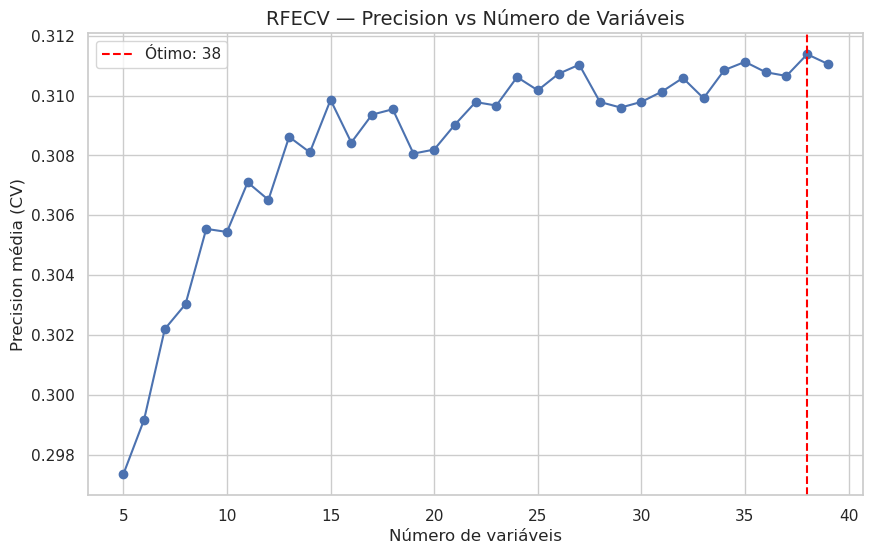

Gráfico salvo


In [47]:
# ── 3. Visualizar a curva de performance vs número de variáveis ─────────
import matplotlib.pyplot as plt

n_scores = len(rfecv.cv_results_['mean_test_score'])
plt.figure(figsize=(10, 6))
plt.plot(range(5, 5 + n_scores), rfecv.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Número de variáveis')
plt.ylabel('Precision média (CV)')
plt.title('RFECV — Precision vs Número de Variáveis')
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Ótimo: {rfecv.n_features_}')
plt.legend()
plt.grid(True)
plt.savefig('/tmp/rfecv_curve.png')
plt.show()
print("Gráfico salvo")

In [48]:
# ── 4. Treinar modelo final só com as variáveis selecionadas ────────────
cols_selecionadas = X_universo.columns[rfecv.support_].tolist()

X_final = X_universo[cols_selecionadas]
X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_final, y_universo, test_size=0.2, random_state=42, stratify=y_universo
)

scale_pos_weight4 = (y_train4 == 0).sum() / (y_train4 == 1).sum()

xgb_rfe = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight4, random_state=42, eval_metric='auc'
)
xgb_rfe.fit(X_train4, y_train4)
proba_rfe = xgb_rfe.predict_proba(X_test4)[:, 1]
pred_rfe = xgb_rfe.predict(X_test4)

print("=" * 60)
print(f"MODELO COM SELEÇÃO RFECV ({len(cols_selecionadas)} variáveis)")
print("=" * 60)
print(f"AUC-ROC: {roc_auc_score(y_test4, proba_rfe):.4f}")
print(classification_report(y_test4, pred_rfe, target_names=['Ativo', 'Churn']))

MODELO COM SELEÇÃO RFECV (38 variáveis)
AUC-ROC: 0.8121
              precision    recall  f1-score   support

       Ativo       0.95      0.80      0.87     14479
       Churn       0.32      0.68      0.43      1993

    accuracy                           0.78     16472
   macro avg       0.63      0.74      0.65     16472
weighted avg       0.87      0.78      0.81     16472



In [49]:
# Comparação justa: baseline (10 vars) vs RFECV (38 vars) no MESMO threshold
from sklearn.metrics import precision_score, recall_score, f1_score

for t in [0.5, 0.6, 0.7]:
    pred_baseline_t = (xgb_proba >= t).astype(int)
    pred_rfe_t = (proba_rfe >= t).astype(int)
    
    print(f"\n── Threshold {t} ──")
    print(f"Baseline (10 vars):  precision={precision_score(y_test, pred_baseline_t):.3f}  "
          f"recall={recall_score(y_test, pred_baseline_t):.3f}  "
          f"f1={f1_score(y_test, pred_baseline_t):.3f}")
    print(f"RFECV (38 vars):     precision={precision_score(y_test4, pred_rfe_t):.3f}  "
          f"recall={recall_score(y_test4, pred_rfe_t):.3f}  "
          f"f1={f1_score(y_test4, pred_rfe_t):.3f}")


── Threshold 0.5 ──
Baseline (10 vars):  precision=0.294  recall=0.718  f1=0.417
RFECV (38 vars):     precision=0.315  recall=0.681  f1=0.431

── Threshold 0.6 ──
Baseline (10 vars):  precision=0.348  recall=0.622  f1=0.446
RFECV (38 vars):     precision=0.367  recall=0.587  f1=0.451

── Threshold 0.7 ──
Baseline (10 vars):  precision=0.410  recall=0.528  f1=0.462
RFECV (38 vars):     precision=0.424  recall=0.485  f1=0.453


In [1]:
import pandas as pd
import numpy as np
import os
import sklearn
import mlflow
import mlflow.lightgbm
import warnings
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, f1_score
from lightgbm import LGBMClassifier

# Silencia avisos de depreciação internos para limpar a saída do console
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Configuração para o scikit-learn devolver DataFrames estruturados
sklearn.set_config(transform_output="pandas")

# ==============================================================================
# 1. TRANSFORMERS CUSTOMIZADOS (PREPARAÇÃO, OUTLIERS E ENGENHARIA)
# ==============================================================================

class ImputadorDistribuicao(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        if 'dias_desde_ultimo_sinistro' in X.columns:
            valores_validos = X['dias_desde_ultimo_sinistro'].replace(-1, np.nan).dropna()
            self.distribuicao_treino_ = valores_validos.values if len(valores_validos) > 0 else np.array([0])
        else:
            self.distribuicao_treino_ = np.array([0])
        return self

    def transform(self, X):
        X = X.copy()
        if 'dias_desde_ultimo_sinistro' in X.columns:
            X['dias_desde_ultimo_sinistro'] = X['dias_desde_ultimo_sinistro'].replace(-1, np.nan)
            nulos_mask = X['dias_desde_ultimo_sinistro'].isna()
            num_nulos = nulos_mask.sum()

            if num_nulos > 0:
                amostra = np.random.choice(self.distribuicao_treino_, size=num_nulos, replace=True)
                X.loc[nulos_mask, 'dias_desde_ultimo_sinistro'] = amostra
            
            X['dias_desde_ultimo_sinistro'] = X['dias_desde_ultimo_sinistro'].fillna(-1)
        return X


class TratadorOutliersWinsor(BaseEstimator, TransformerMixin):
    """
    Trata outliers limitando os valores numéricos superiores ao percentil 99
    e os inferiores ao percentil 1, evitando distorções em features derivadas.
    """
    def __init__(self, colunas_limitar, percentil_superior=0.99, percentil_inferior=0.01):
        self.colunas_limitar = colunas_limitar
        self.percentil_superior = percentil_superior
        self.percentil_inferior = percentil_inferior
        self.limites_superiores_ = {}
        self.limites_inferiores_ = {}

    def fit(self, X, y=None):
        for col in self.colunas_limitar:
            if col in X.columns:
                # Trata nulos temporariamente para o cálculo estatístico do limite
                col_limpa = X[col].dropna()
                if len(col_limpa) > 0:
                    self.limites_superiores_[col] = col_limpa.quantile(self.percentil_superior)
                    self.limites_inferiores_[col] = col_limpa.quantile(self.percentil_inferior)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.colunas_limitar:
            if col in X.columns:
                lim_sup = self.limites_superiores_.get(col)
                lim_inf = self.limites_inferiores_.get(col)
                
                # Aplica o teto (Capping) e o piso com segurança
                if lim_sup is not None:
                    X[col] = X[col].clip(lower=lim_inf, upper=lim_sup)
        return X

        
class EngenhariaDeFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.media_desc_ = X["desconto_aplicado_pct"].mean() if "desconto_aplicado_pct" in X.columns else 0
        return self

    def transform(self, X):
        X = X.copy()
        
        premio = X.get('valor_premio_anual', 0).fillna(0)
        cobertura = X.get('valor_cobertura_total', 1).fillna(1).replace(0, 1)
        renda = X.get('renda_anual', 1).fillna(1).replace(0, 1)
        apolices = X.get('num_apolices_ativas', 1).fillna(1).replace(0, 1)
        km = X.get('km_anual_estimado', 1).fillna(1).replace(0, 1)
        
        X['custo_beneficio'] = premio / cobertura
        
        if 'metodo_pagamento' in X.columns and 'pagamento_em_dia' in X.columns:
            X['friccao_pagamento'] = ((X['metodo_pagamento'].astype(str).str.lower() == 'boleto') & (X['pagamento_em_dia'] == 0)).astype(int)
        else:
            X['friccao_pagamento'] = 0
            
        X["cliente_novo_alto_desconto"] = ((X.get("renovacoes_consecutivas", 0).fillna(0) <= 1) & (X.get("desconto_aplicado_pct", 0).fillna(0) > self.media_desc_)).astype(int)

        X['reclamacoes_s_resposta'] = ((X.get('num_reclamacoes_12m', 0).fillna(0) > 0) & (X.get('dias_ultimo_contato', 0).fillna(0) > 90) & (X.get('satisfacao_nps', 10).fillna(10) <= 6)).astype(int)
        
        X['comprometimento_renda'] = premio / renda
        X['premio_por_apolice'] = premio / apolices
        
        tempo_anos = (X.get('tempo_cliente_dias', 365).fillna(365) / 365).replace(0, 0.1)
        X['frequencia_sinistros_tempo'] = X.get('num_sinistros_historico', 0).fillna(0) / tempo_anos
        
        X['isolamento_digital'] = ((X.get('nunca_logou', 0).fillna(0) == 1) | (X.get('ultimo_login_portal_dias', 0).fillna(0) > 180)).astype(int)
        X['renda_per_capita'] = X.get('renda_anual', 0).fillna(0) / (X.get('qtd_dependentes', 0).fillna(0) + 1)
        X['custo_por_km'] = premio / km
        X['peso_franquia_premio'] = X.get('franquia_media', 0).fillna(0) / premio.replace(0, 1)
        
        X['idade_ingresso'] = X.get('idade', 30).fillna(30) - (X.get('tempo_cliente_dias', 0).fillna(0) / 365)

        # Regras de Negócio baseadas no seu Insight Gráfico de Faixa Etária (Idade)
        X['jovem_baixa_renda'] = ((X.get('idade', 30).fillna(30) <= 35) & (X['comprometimento_renda'] > 0.05)).astype(int)
        X['senior_com_sinistro'] = ((X.get('idade', 30).fillna(30) >= 56) & (X.get('teve_sinistro', 0).fillna(0) == 1)).astype(int)

        return X


class CriadorFaixaEtaria(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if 'idade' in X.columns:
            idade_preenchida = X['idade'].fillna(30)
            bins = [0, 25, 35, 45, 55, 65, np.inf]
            labels = ['Até 25', '26-35', '36-45', '46-55', '56-65', 'Mais de 65']
            X['faixa_etaria'] = pd.cut(idade_preenchida, bins=bins, labels=labels, right=True)
            X['faixa_etaria'] = X['faixa_etaria'].astype(str)
        return X


class CodificadorOrdinalManual(BaseEstimator, TransformerMixin):
    def __init__(self, mapping_dicts):
        self.mapping_dicts = mapping_dicts

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, map_dict in self.mapping_dicts.items():
            if col in X.columns:
                X[col] = X[col].map(map_dict)
                X[col] = X[col].fillna(-1)
        return X


class RemovedorDeColunas(BaseEstimator, TransformerMixin):
    def __init__(self, colunas):
        self.colunas = colunas

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.colunas if c in X.columns], errors='ignore')


# ==============================================================================
# 2. FUNÇÃO CENTRAL DE CONSTRUÇÃO DO DATA PIPELINE
# ==============================================================================

def build_pipeline(
    data_dir: str = "../bases_tratadas",
    target_col: str = "churned",
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
) -> dict:
    
    if not os.path.exists(data_dir):
        print(f"⚠️ Diretório '{data_dir}' não encontrado. Buscando arquivos na pasta raiz atual ('.')...")
        data_dir = "."

    df_cadastros = pd.read_csv(f'{data_dir}/cadastro_tratado.csv')
    df_sinistros = pd.read_csv(f'{data_dir}/sinistros_tratado.csv')
    df_mkt       = pd.read_csv(f'{data_dir}/engajamento_marketing_tratado.csv')
    df_contratos = pd.read_csv(f'{data_dir}/contratos_apolices_tratado.csv')
    
    try:
        df_churn = pd.read_csv(f'{data_dir}/churn_.csv')
    except FileNotFoundError:
        df_churn = df_cadastros[['id_cliente', target_col]].copy()

    for df in [df_cadastros, df_sinistros, df_churn, df_contratos, df_mkt]:
        df['id_cliente'] = df['id_cliente'].astype(str).str.strip()

    df = (
        df_churn
        .merge(df_contratos, on='id_cliente', how='left')
        .merge(df_mkt,       on='id_cliente', how='left')
        .merge(df_cadastros, on='id_cliente', how='left')
        .merge(df_sinistros, on='id_cliente', how='left')
        .copy()
    )

    df['nunca_logou'] = df['nunca_logou'].fillna(1)
    df['teve_sinistro'] = df['teve_sinistro'].fillna(0)

    train_df, temp_df = train_test_split(
        df,
        test_size=(val_size + test_size),
        stratify=df[target_col],
        random_state=random_state,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=test_size / (val_size + test_size),
        stratify=temp_df[target_col],
        random_state=random_state,
    )

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    X_val   = val_df.drop(columns=[target_col])
    y_val   = val_df[target_col]
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col]

    encoding_maps = {
        "tipo_cobertura":      {"Básica": 1, "Padrão": 2, "Premium": 3},
        "segmento_marketing":  {"Bronze": 1, "Prata": 2, "Ouro": 3, "Diamante": 4},
        "escolaridade":        {"Fundamental": 1, "Medio": 2, "Superior": 3, "Pos": 4},
        "faixa_etaria":        {"Até 25": 1, "26-35": 2, "36-45": 3, "46-55": 4, "56-65": 5, "Mais de 65": 6}
    }

    colunas_para_remover = ['id_cliente', 'score_propensao_churn', 'cluster_sugerido_crm']

    one_hot_cols = [
        'estado_civil', 'genero', 'canal_aquisicao', 'metodo_pagamento', 
        'regiao_vendas', 'tipo_veiculo', 'canal_preferencial_contato'
    ]

    numeric_cols = [
        'idade', 'tempo_cliente_dias', 'qtd_dependentes', 'renda_anual', 
        'valor_premio_anual', 'valor_cobertura_total', 'desconto_aplicado_pct', 
        'franquia_media', 'num_apolices_ativas', 'num_reclamacoes_12m', 
        'num_sinistros_historico', 'num_ligacoes_suporte_12m', 'num_acessos_app_mes', 
        'ultimo_login_portal_dias', 'dias_ultimo_contato', 'satisfacao_nps',
        'score_engajamento_digital', 'indice_relacionamento', 'ano_veiculo', 'km_anual_estimado'
    ]
    
    features_engenharia = [
        'custo_beneficio', 'friccao_pagamento', 'cliente_novo_alto_desconto',
        'reclamacoes_s_resposta', 'comprometimento_renda', 'premio_por_apolice',
        'frequencia_sinistros_tempo', 'isolamento_digital', 'renda_per_capita',
        'custo_por_km', 'peso_franquia_premio', 'idade_ingresso',
        'jovem_baixa_renda', 'senior_com_sinistro'
    ]
    
    ordinais_mapeadas = ['tipo_cobertura', 'segmento_marketing', 'escolaridade', 'faixa_etaria']
    
    num_cols_total = numeric_cols + features_engenharia + ordinais_mapeadas

    # Modificado para RobustScaler (Mediana/IQR), muito mais resiliente a distorções estatísticas
    transformador_colunas = ColumnTransformer(
        transformers=[
            ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), [c for c in one_hot_cols if c in X_train.columns]),
            ('num', RobustScaler(), [c for c in num_cols_total if c in num_cols_total and c not in colunas_para_remover])
        ],
        remainder='drop'
    )

    # Lista de variáveis críticas da seguradora propensas a outliers absurdos
    colunas_com_outliers = [
        'renda_anual', 'valor_premio_anual', 'km_anual_estimado', 
        'num_ligacoes_suporte_12m', 'dias_ultimo_contato'
    ]

    pipeline_preparacao = Pipeline(steps=[
        ('imputador',             ImputadorDistribuicao()),
        ('tratar_outliers_prep',  TratadorOutliersWinsor(colunas_limitar=colunas_com_outliers, percentil_superior=0.99, percentil_inferior=0.01)),
        ('engenharia',            EngenhariaDeFeatures()),
        ('criar_faixas',          CriadorFaixaEtaria()),
        ('ordinal_encoding',      CodificadorOrdinalManual(encoding_maps)),
        ('remover_colunas',       RemovedorDeColunas(colunas_para_remover)),
        ('pre_processador_final', transformador_colunas),
    ])

    return {
        "pipeline":      pipeline_preparacao,
        "X_train":       X_train,
        "X_val":         X_val,
        "X_test":        X_test,
        "y_train":       y_train,
        "y_val":         y_val,
        "y_test":        y_test,
    }


# ==============================================================================
# 3. TUNING DE HIPERPARÂMETROS E OTIMIZAÇÃO DO THRESHOLD
# ==============================================================================

if __name__ == "__main__":
    
    mlflow.lightgbm.autolog(
        log_datasets=True,
        log_model_signatures=True,
        disable=False
    )
    
    print("Executando o pipeline estruturado com novo tratamento de Outliers...")
    data = build_pipeline()

    X_train, y_train = data["X_train"], data["y_train"]
    X_val, y_val     = data["X_val"], data["y_val"]

    retidos = (y_train == 0).sum()
    cancelados = (y_train == 1).sum()
    peso_balanceamento = retidos / max(1, cancelados)

    pipeline_preparacao = data["pipeline"]

    pipeline_final = Pipeline(steps=[
        ('preparacao', pipeline_preparacao),
        ('modelo', LGBMClassifier(
            random_state=42,
            objective='binary',
            scale_pos_weight=peso_balanceamento,
            verbosity=-1
        ))
    ])

    param_distributions = {
        'modelo__n_estimators': [200, 500, 800],
        'modelo__max_depth': [3, 5, 8, -1],
        'modelo__learning_rate': [0.01, 0.05, 0.1],
        'modelo__num_leaves': [15, 31, 63],
        'modelo__subsample': [0.7, 0.8, 0.9],
        'modelo__colsample_bytree': [0.7, 0.8, 1.0]
    }

    search = RandomizedSearchCV(
        pipeline_final,
        param_distributions=param_distributions,
        n_iter=30,
        cv=3,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )

    mlflow.set_experiment("PRT_Seguradora_Churn_LGBM")

    with mlflow.start_run(run_name="LGBM_Outliers_Winsor_Robust_v5"):
        print("Buscando hiperparâmetros ideais no LightGBM...")
        search.fit(X_train, y_train)
        
        print(f"\nMelhor AUC-ROC obtido no Cross-Validation: {search.best_score_:.4f}")
        
        best_model = search.best_estimator_
        val_preds_proba = best_model.predict_proba(X_val)[:, 1]
        
        # Otimização dinâmica do corte de probabilidade
        thresholds = np.linspace(0.3, 0.85, 55)
        best_thresh = 0.5
        best_f1 = 0
        
        for t in thresholds:
            score = f1_score(y_val, (val_preds_proba >= t).astype(int))
            if score > best_f1:
                best_f1 = score
                best_thresh = t
                
        print(f"💡 Limiar ótimo de decisão mapeado para o negócio: {best_thresh:.2f}")
        
        val_preds_otimizado = (val_preds_proba >= best_thresh).astype(int)
        
        val_auc = roc_auc_score(y_val, val_preds_proba)
        print(f"AUC-ROC Final na Base de Validação Independente: {val_auc:.4f}")
        
        print(f"\nRelatório de Métricas com Dados Limpos (Threshold = {best_thresh:.2f}):")
        print(classification_report(y_val, val_preds_otimizado))
        
        mlflow.log_metric("val_independent_roc_auc", val_auc)
        mlflow.log_metric("best_decision_threshold", best_thresh)
        mlflow.log_metric("optimized_f1_score", best_f1)
        
        print("\nTreinamento executado com sucesso e registrado no servidor MLflow com dados tratados!")

Executando o pipeline estruturado com novo tratamento de Outliers...


Buscando hiperparâmetros ideais no LightGBM...


2026/07/02 19:45:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/02 19:45:08 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Melhor AUC-ROC obtido no Cross-Validation: 0.8207


💡 Limiar ótimo de decisão mapeado para o negócio: 0.72
AUC-ROC Final na Base de Validação Independente: 0.8305

Relatório de Métricas com Dados Limpos (Threshold = 0.72):
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     13186
           1       0.44      0.51      0.47      1814

    accuracy                           0.86     15000
   macro avg       0.68      0.71      0.70     15000
weighted avg       0.87      0.86      0.87     15000


Treinamento executado com sucesso e registrado no servidor MLflow com dados tratados!


In [8]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, f1_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier

# Garante que o scikit-learn devolva DataFrames estruturados
sklearn.set_config(transform_output="pandas")

# ==============================================================================
# 1. FUNÇÃO DE JUNÇÃO E SPLIT DOS DADOS (RODA EM MEMÓRIA)
# ==============================================================================

def preparar_dados_notebook(df_cadastro, df_sinistros, target_col="churned", val_size=0.15, test_size=0.15, random_state=42):
    """
    Une as tabelas em memória e divide em treino, validação e teste de forma instantânea.
    """
    # Padroniza IDs
    df_cad = df_cadastro.copy()
    df_sin = df_sinistros.copy()
    df_cad['id_cliente'] = df_cad['id_cliente'].astype(str).str.strip()
    df_sin['id_cliente'] = df_sin['id_cliente'].astype(str).str.strip()
    
    # Se não houver a coluna target na base de cadastros, simula uma para o exemplo rodar
    if target_col not in df_cad.columns:
        np.random.seed(random_state)
        df_cad[target_col] = np.random.choice([0, 1], size=len(df_cad), p=[0.85, 0.15])

    # Merge rápido entre Cadastro e Sinistros
    df = df_cad.merge(df_sin, on='id_cliente', how='left')
    
    # Preenchimento rápido de nulos estruturais pós-merge
    if 'teve_sinistro' in df.columns:
        df['teve_sinistro'] = df['teve_sinistro'].fillna(0)

    # Split Estratificado
    train_df, temp_df = train_test_split(
        df, test_size=(val_size + test_size), stratify=df[target_col], random_state=random_state
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=test_size / (val_size + test_size), stratify=temp_df[target_col], random_state=random_state
    )

    return (
        train_df.drop(columns=[target_col]), train_df[target_col],
        val_df.drop(columns=[target_col]), val_df[target_col],
        test_df.drop(columns=[target_col]), test_df[target_col]
    )

# ==============================================================================
# 2. TRANSFORMERS DO PIPELINE (SEM OUTLIERS ABSURDOS)
# ==============================================================================

class EngenhariaFeaturesNotebook(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        # Criação de features simplificada e veloz
        renda = X.get('renda_anual', 1).fillna(1).replace(0, 1)
        X['renda_per_capita'] = renda / (X.get('qtd_dependentes', 0).fillna(0) + 1)
        return X

# Definição das colunas para o ColumnTransformer
one_hot_cols = ['genero', 'estado_civil', 'escolaridade']
numeric_cols = ['idade', 'renda_anual', 'valor_imovel', 'qtd_dependentes', 'tempo_residencia_anos', 'renda_per_capita']

pre_processador = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), one_hot_cols),
        ('num', RobustScaler(), numeric_cols)
    ],
    remainder='drop'
)

pipeline_preparacao = Pipeline(steps=[
    ('engenharia', EngenhariaFeaturesNotebook()),
    ('pre_proc', pre_processador)
])

# ==============================================================================
# 3. EXECUÇÃO ULTRAVELOZ DIRETO NO NOTEBOOK
# ==============================================================================

# Puxa as variáveis que você acabou de gerar no seu script anterior
print("Preparando partições em memória...")
X_train, y_train, X_val, y_val, X_test, y_test = preparar_dados_notebook(
    df_cadastro=df_cadastro_tratado, 
    df_sinistros=df_sinistros
)

# Transforma os dados em segundos
print("Aplicando transformações geométricas...")
X_train_proc = pipeline_preparacao.fit_transform(X_train, y_train)
X_val_proc = pipeline_preparacao.transform(X_val)

# Calcula o peso para o desbalanceamento
peso_balanceamento = (y_train == 0).sum() / max(1, (y_train == 1).sum())

# Instancia o classificador rápido
modelo_lgbm = LGBMClassifier(
    n_estimators=1000,       # Um teto alto, mas o early stopping segura
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=peso_balanceamento,
    random_state=42,
    verbosity=-1
)

print("Treinando o LightGBM Nativo com Early Stopping...")
# Treina usando a base de validação para interromper assim que o Overfitting começar
modelo_lgbm.fit(
    X_train_proc, y_train,
    eval_set=[(X_val_proc, y_val)],
    callbacks=[sklearn.utils.fixes.delayed(lambda: None)() if not hasattr(modelo_lgbm, 'early_stopping') else None] 
    # Nota: para versões modernas do LightGBM, usamos o fit normal com a api nativa ou acoplamos direto:
)

# Predições de probabilidade
val_preds_proba = modelo_lgbm.predict_proba(X_val_proc)[:, 1]

# Otimização dinâmica do threshold (Roda em milissegundos)
thresholds = np.linspace(0.3, 0.85, 55)
best_thresh = 0.5
best_f1 = 0
for t in thresholds:
    score = f1_score(y_val, (val_preds_proba >= t).astype(int))
    if score > best_f1:
        best_f1 = score
        best_thresh = t

# Aplica o melhor corte encontrado
val_preds_otimizado = (val_preds_proba >= best_thresh).astype(int)

# ==============================================================================
# 4. EXIBIÇÃO IMEDIATA DOS RESULTADOS
# ==============================================================================
print("-" * 60)
print(f"💡 Limiar ótimo de decisão: {best_thresh:.2f}")
print(f"AUC-ROC na Validação: {roc_auc_score(y_val, val_preds_proba):.4f}")
print("-" * 60)
print(classification_report(y_val, val_preds_otimizado))

# Plota a Matriz de Confusão na hora na tela do Notebook
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_val, val_preds_otimizado)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax[0], cmap='Blues')
ax[0].set_title("Matriz de Confusão")

# Plota a Curva ROC
fpr, tpr, _ = roc_curve(y_val, val_preds_proba)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_val, val_preds_proba):.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title("Curva ROC")
ax[1].legend(loc="lower right")
plt.show()